In [1]:
# Goal of this notebook is to implement the dynamical model of Neggers et al. (2006).
# Figure 4 of Neggers et al. (2006) is reproduced, but the equilibrium values do not coincide with theirs.
# They coincide with those published by Youtong Zheng here https://github.com/youtongzheng/Neggers_2006.

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

import pandas as pd

import sys; sys.path.insert(1, './bulk_model_code.py')

## these files contain all functions definiing bulk model, saturation humidities, LCL ...
import bulk_model_code

In [2]:
%load_ext autoreload
%autoreload 2

# Neggers et al. (2006) model

The model numerically solves the following three equations for the ABL height $h$, total specific humidity $q_t$ and liquid water potential temperature $\theta_l$
$$ \frac{\partial h}{\partial t} = E + w - M $$
$$ h\frac{\partial q_t}{\partial t} = \overline{w'q_t'}_s + E \Delta q_t + hF_{adv,q_t} $$
$$ h\frac{\partial \theta_l}{\partial t} = \overline{w'\theta_l'}_s + E\Delta\theta_l + hF_{adv,\theta_l} + hF_{rad}, $$
where the surface fluxes are represented with the bulk formulae
$$\overline{w'q_t'}_s = |\boldsymbol{u}_s|C_q^s(q_t^s-q_t)$$
$$\overline{w'\theta_l'}_s = |\boldsymbol{u}_s|C_\theta^s(\theta_l^s-\theta_l)$$
with  $C_q^s = C_\theta^s = 0.0012$, $\boldsymbol{u}_s$ being the surface wind and $q_t^s$ and $\theta_l^s$ the surface properties. The symbol $\Delta$ denotes the jump across the transition layer and not the difference between the free atmosphere and ABL values.

Remind that the liquid water potential temperature can be approximated with 
$$ \theta_l = \theta - \frac{L_v}{c_{pd}}r_l,$$
with $L_v$ the latent heat of vaporization, $c_{pd}$ the specific heat of dry air at constant pressure and $r_l$ the liquid water mixing ratio.

Starting from the equation for $h$, the entrainment $E$ has the units of a velocity and it appears in the virtual potential temperature flux at the ABL top as
$$\overline{w'\theta_v'}_h = E\Delta\theta. $$
From the definition of virtual potential temperature, $\theta_v = \theta(1+0.61q_t-1.61q_l)$, assuming no liquid water, $q_l = 0$, the jump in $\theta_v$ at the ABL top can be explicitly written as
$$\Delta\theta_v = \Delta\theta+ 0.61(\theta\Delta q_t+q_t\Delta\theta+\Delta q_t\Delta\theta).$$

The transition layer jumps are related to the difference w.r.t. the free atmospheric values with some transfer coefficients that represent the cloud layer
$$\Delta q_t = C_q^c (q_t^+-q_t)$$
$$\Delta \theta_l = C_\theta^c (\theta_l^+-\theta_l),$$
with $C_q^c = 0.1$ and $C_\theta^c = 0.03$ from LES hourly mean profiles.

Similarly, the link between the virtual potential temperature flux and the other fluxes is 
$$\overline{w'\theta_v'} = (1+0.61q_t)\overline{w'\theta_l'} + 0.61\theta\overline{w'q_t'}$$
(Cuijpers and Betchold, 1995), neglecting the liquid water specific humidity term.

But the ABL top virtual potential temperature flux has been shown to be proportional to the surface virtual potential temperature flux as
$$ \overline{w'\theta_v'}_h = -0.2 \overline{w'\theta_v'}_s. $$
Thus, the entrainment can be written as 
$$ E = 0.2\frac{\overline{w'\theta_v'}_s}{\Delta\theta_v} $$

The vertical velocity at the ABL top, $w$, is easily imposed as a boundary condition, knowing the large scale subsidence $D$, through mass conservation, namely
$$ w = -hD .$$

The mass flux term $M$ is parameterized as the product of a vertical velocity scale, which has been identified with the Deardorff convective velocity scale $w_*$, and a fractional area of shallow convection $a_c$. Thus,
$$ M = a_cw_*,$$
with 
$$ w_* = (h\overline{w'b'}_s)^{1/3}, $$
$\overline{w'b'}_s = g\overline{w'\theta_v'}_s/\theta_v$ being the surface buoyancy flux. The moist convective area fraction is written as a function of the normalized saturation deficit at the ABL top, namely
$$a_c = 0.5 + 0.36 \arctan\left(1.55\frac{q_t-q_{sat}}{\sigma_q}\right),$$
where $q_{sat}$ is the saturation specific humidity at the ABL top and $\sigma_q^2$, the specific humidity turbulent variance at the ABL top, can be expressed as
$$ \sigma_q^2 = -\frac{h}{w_*}\frac{\Delta q_t}{\Delta z}\overline{w'q_t'}_s.$$
$\Delta z=100$ m is the estimated depth of the cloud transition layer.

test model sensitivity to parameters:
 - SST
 - D
 - $q^+$
 - $\theta_l^+$
 - advection q, $\theta$
 - radiative cooling 

 The forced WRF run has mean values of such variables:
 - SST = 299.8 K
 - D [average between 800-500 hPa ca.] = -4.6e-7 (?)
 - $q^+$ [820 hPa] = 4.6e-3 kg/kg
 - $\theta_l^+$ = 305.16 K
 - $U^+$ , $V^+$ [at 900 hPa] = -9.4 m/s , -3.3 m/s 
 - $F_{adv, Q}$ = -0.6 $g~kg^{-1}~day^{-1}$
 - $F_{adv, \theta}$ = -1.1 $K~day^{-1}$

In [23]:
# Compute the wind components (to be used as free tropospheric wind) starting from the surface wind used in 
'''# Neggers et al (2006).
magnitude = 8.75 # [m/s]
angle = 67.5 # [°] clockwise from north
windu = magnitude*np.sin(angle*np.pi/180)
windv = magnitude*np.cos(angle*np.pi/180)

U_free = -windu # [m/s], free zonal wind (above the ABL).
V_free = -windv # [m/s], free meridional wind (above the ABL).

print(U_free)
print(V_free)'''

U_free_0 = -9.4 # [m/s], free zonal wind (above the ABL).
V_free_0 = -3.3 # [m/s], free meridional wind (above the ABL).

Omega = 2*np.pi/86400 # [rad/s] Earth rotation.
latitude0 = 10 # degree N
f = Omega * np.sin(latitude0*np.pi/180)

In [24]:
#############################   CHOICE OF MODEL EQUATIONS  #################################
equations_model = bulk_model_code.neggers_et_al_2006_stevens_et_al_2002_fracUstar_sensitivity


#######################  set parameters and initial conditions from here on  #####################
frac_Ustar = 0.9

# Initial conditions: y0 = [h(0),q(0),th(0),U(0),V(0)]
cpd  = 1004.67                  # J/K/kg, dry air specific heat at constant pressure
Rd = 287.1                      # J/K/kg, dry air gas constant

####  set initial conditions  ####
 
# Input parameters
D       = np.linspace(-20.0e-6, 20.0e-6, 10)
q_free  = np.linspace(2.0e-3, 12.0e-3, 10)
th_free = np.linspace(305, 312, 10)

U_free = np.linspace(-10, 10, 10)
V_free = np.linspace(-5, 5, 10)


SST_0 = 299.8                                          # [K], sea surface temperature
D_0_base = -4.6e-7                                     # [1/s], large scale divergence                            
q_free_0_base = 4.6e-3                                 # [kg/kg] free tropospheric total mixing ratio               
ps_0 = 1013                                            # [hPa], surface pressure
ref_p = 1000                                           # [hPa], reference pressure for the potential temperature
th_free_0_base = 305.16                                # [K], free tropospheric liquid virtual potential temperature  # np.linspace(303, 310)
th_s = SST_0*(ref_p/ps_0)**(Rd/cpd)                    # surface liquid water potential temperature, assuming no liquid water at the surface
q_s = bulk_model_code.qsea(SST_0-273.15,ps_0)*1e-3


#####  advective fluxes and radiative cooling sensitivities  #####
F_advTh_base = -1.1/86400.
F_advQ_base  = -0.6e-3/86400.
F_rad_base   = -2./86400

F_advTh = np.linspace(-1./86400, 1./86400, 10)          # K / day
F_advQ  = np.linspace(-1.e-3/86400, 1.e-3/86400, 10)    # g/kg / day
F_rad   = np.linspace(-3./86400, 0.05/86400, 10)         # K / day

# adjust initial conditions (boundary layer humidity) depending on SST value!
y0 = [500, q_s - 5e-3, th_s-3, U_free, V_free]  

print(y0)

## set integration times
max_t = 3.5e5
dt_max = 60
time = [0, max_t]

t_eval_eq = np.arange(0,max_t,dt_max)

[500, np.float64(0.0168190441680946), 295.69547448881485, array([-10.        ,  -7.77777778,  -5.55555556,  -3.33333333,
        -1.11111111,   1.11111111,   3.33333333,   5.55555556,
         7.77777778,  10.        ]), array([-5.        , -3.88888889, -2.77777778, -1.66666667, -0.55555556,
        0.55555556,  1.66666667,  2.77777778,  3.88888889,  5.        ])]


In [ ]:
D_sens = {}

for d in D:
    args = (SST_0, d, q_free_0_base, th_free_0_base, ps_0, f, U_free_0, V_free_0, frac_Ustar, F_advQ_base, F_advTh_base, F_rad_base)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    try:
        sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
        if sol.success == False:
            raise RuntimeError("Integration failed.")
    except RuntimeError:
        print(f"Integration failed for D = {d}.")
        continue
    # sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
    #                     dense_output=True, max_step=dt_max, args=args)
    
    D_sens[d] = sol

    print(f"D = {d}, done.")


D = -2e-05, done.
D = -1.5555555555555555e-05, done.
D = -1.1111111111111112e-05, done.
D = -6.666666666666667e-06, done.
D = -2.2222222222222217e-06, done.
D = 2.2222222222222217e-06, done.
D = 6.666666666666668e-06, done.
D = 1.1111111111111115e-05, done.
D = 1.555555555555556e-05, done.
D = 2e-05, done.


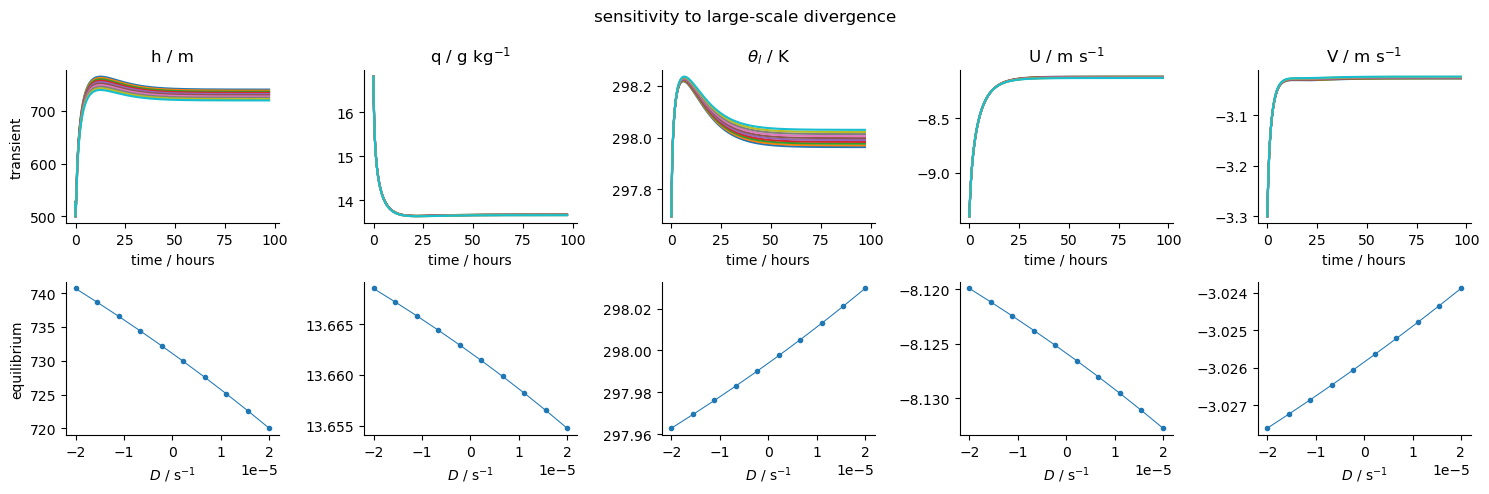

In [22]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle("sensitivity to large-scale divergence")
ax = ax.flatten()

for i in D_sens.keys():
    ax[0].plot(D_sens[i].t/3600, D_sens[i].y[0])
    ax[1].plot(D_sens[i].t/3600, (D_sens[i].y[1])*1e3)
    ax[2].plot(D_sens[i].t/3600, D_sens[i].y[2])
    ax[3].plot(D_sens[i].t/3600, D_sens[i].y[3])
    ax[4].plot(D_sens[i].t/3600, D_sens[i].y[4])

ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")


#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in D_sens.keys():
    h_eq.append(D_sens[i].y[0][-1])
    q_eq.append((D_sens[i].y[1][-1])*1e3)
    t_eq.append(D_sens[i].y[2][-1])
    u_eq.append(D_sens[i].y[3][-1])
    v_eq.append(D_sens[i].y[4][-1])

ax[5].plot(D, h_eq, ".-", linewidth=0.75)
ax[6].plot(D, q_eq, ".-", linewidth=0.75)
ax[7].plot(D, t_eq, ".-", linewidth=0.75)
ax[8].plot(D, u_eq, ".-", linewidth=0.75)
ax[9].plot(D, v_eq, ".-", linewidth=0.75)


ax[5].set_ylabel("equilibrium")


from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax[7].yaxis.set_major_formatter(formatter)


for x in ax[5:]:
    x.set_xlabel(r"$D$ / $\rm s^{-1}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)





plt.tight_layout()

In [ ]:
q_free_sens = {}

for q in q_free:
    args = (SST_0, D_0_base, q, th_free_0_base, ps_0, f, U_free_0, V_free_0, frac_Ustar, F_advQ_base, F_advTh_base, F_rad_base)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    try:
        sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
        if sol.success == False:
            raise RuntimeError("Integration failed.")
    except RuntimeError:
        print(f"Integration failed for q = {q}.")
        continue
    
    q_free_sens[q] = sol

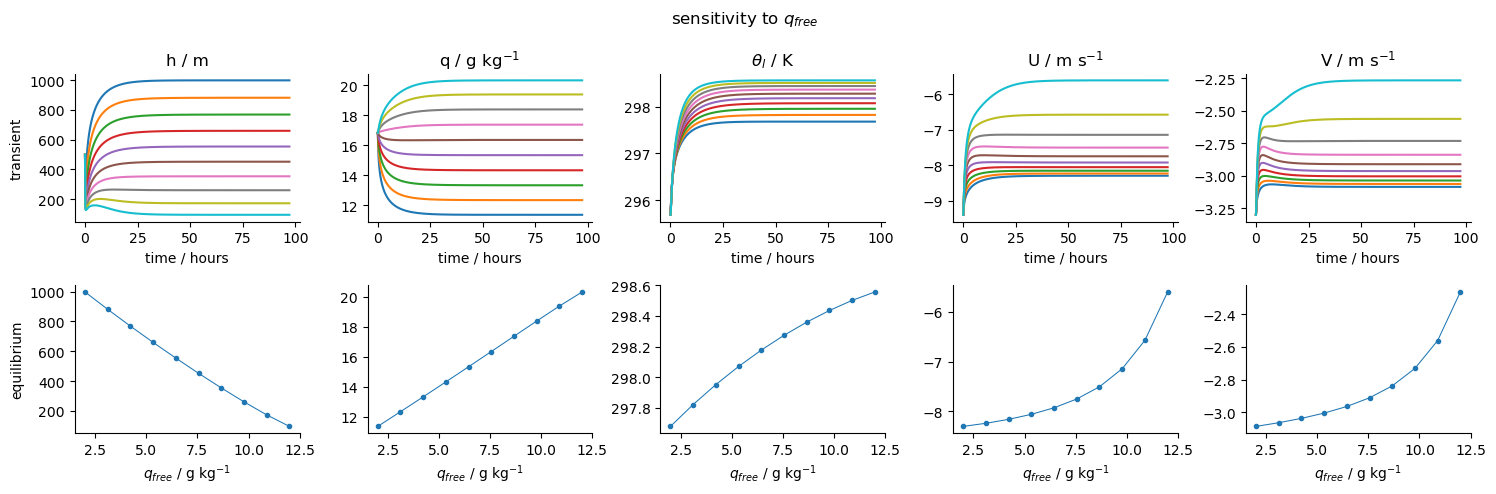

In [12]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle(r"sensitivity to $q_{free}$")
ax = ax.flatten()

for i in q_free_sens.keys():
    ax[0].plot(q_free_sens[i].t/3600, q_free_sens[i].y[0])
    ax[1].plot(q_free_sens[i].t/3600, 1e3*q_free_sens[i].y[1])
    ax[2].plot(q_free_sens[i].t/3600, q_free_sens[i].y[2])
    ax[3].plot(q_free_sens[i].t/3600, q_free_sens[i].y[3])
    ax[4].plot(q_free_sens[i].t/3600, q_free_sens[i].y[4])




ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")


#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in q_free_sens.keys():
    h_eq.append(q_free_sens[i].y[0][-1])
    q_eq.append((q_free_sens[i].y[1][-1])*1e3)
    t_eq.append(q_free_sens[i].y[2][-1])
    u_eq.append(q_free_sens[i].y[3][-1])
    v_eq.append(q_free_sens[i].y[4][-1])

ax[5].plot(q_free*1e3, h_eq, ".-", linewidth=0.75)
ax[6].plot(q_free*1e3, q_eq, ".-", linewidth=0.75)
ax[7].plot(q_free*1e3, t_eq, ".-", linewidth=0.75)
ax[8].plot(q_free*1e3, u_eq, ".-", linewidth=0.75)
ax[9].plot(q_free*1e3, v_eq, ".-", linewidth=0.75)


ax[5].set_ylabel("equilibrium")

for x in ax[5:]:
    x.set_xlabel(r"$q_{free}$ / $\rm g~kg^{-1}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

In [ ]:
th_free_sens = {}

for th in th_free:
    args = (SST_0, D_0_base, q_free_0_base, th, ps_0, f, U_free_0, V_free_0, frac_Ustar, F_advQ_base, F_advTh_base, F_rad_base)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
    
    th_free_sens[th] = sol

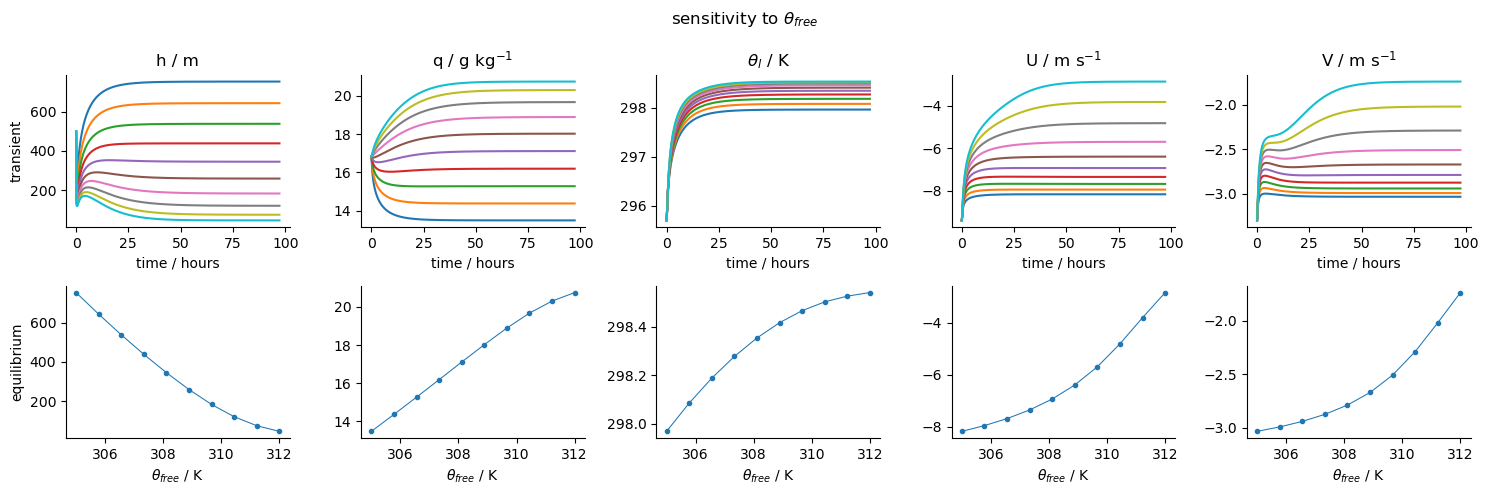

In [14]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle(r"sensitivity to $\theta_{free}$")
ax = ax.flatten()

for i in th_free_sens.keys():
    ax[0].plot(th_free_sens[i].t/3600, th_free_sens[i].y[0])
    ax[1].plot(th_free_sens[i].t/3600, 1e3*th_free_sens[i].y[1])
    ax[2].plot(th_free_sens[i].t/3600, th_free_sens[i].y[2])
    ax[3].plot(th_free_sens[i].t/3600, th_free_sens[i].y[3])
    ax[4].plot(th_free_sens[i].t/3600, th_free_sens[i].y[4])




ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")



#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in th_free_sens.keys():
    h_eq.append(th_free_sens[i].y[0][-1])
    q_eq.append((th_free_sens[i].y[1][-1])*1e3)
    t_eq.append(th_free_sens[i].y[2][-1])
    u_eq.append(th_free_sens[i].y[3][-1])
    v_eq.append(th_free_sens[i].y[4][-1])

ax[5].plot(th_free, h_eq, ".-", linewidth=0.75)
ax[6].plot(th_free, q_eq, ".-", linewidth=0.75)
ax[7].plot(th_free, t_eq, ".-", linewidth=0.75)
ax[8].plot(th_free, u_eq, ".-", linewidth=0.75)
ax[9].plot(th_free, v_eq, ".-", linewidth=0.75)


ax[5].set_ylabel("equilibrium")

for x in ax[5:]:
    x.set_xlabel(r"$\theta_{free}$ / $\rm K$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

In [ ]:
u_free_sens = {}

for u in U_free:
    args = (SST_0, D_0_base, q_free_0_base, th, ps_0, f, U_free, V_free_0, frac_Ustar, F_advQ_base, F_advTh_base, F_rad_base)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
    
    u_free_sens[u] = sol

In [ ]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle(r"sensitivity to $U_{free}$")
ax = ax.flatten()

for i in u_free_sens.keys():
    ax[0].plot(u_free_sens[i].t/3600, u_free_sens[i].y[0])
    ax[1].plot(u_free_sens[i].t/3600, 1e3*u_free_sens[i].y[1])
    ax[2].plot(u_free_sens[i].t/3600, u_free_sens[i].y[2])
    ax[3].plot(u_free_sens[i].t/3600, u_free_sens[i].y[3])
    ax[4].plot(u_free_sens[i].t/3600, u_free_sens[i].y[4])




ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")



#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in u_free_sens.keys():
    h_eq.append(u_free_sens[i].y[0][-1])
    q_eq.append((u_free_sens[i].y[1][-1])*1e3)
    t_eq.append(u_free_sens[i].y[2][-1])
    u_eq.append(u_free_sens[i].y[3][-1])
    v_eq.append(u_free_sens[i].y[4][-1])

ax[5].plot(U_free, h_eq, ".-", linewidth=0.75)
ax[6].plot(U_free, q_eq, ".-", linewidth=0.75)
ax[7].plot(U_free, t_eq, ".-", linewidth=0.75)
ax[8].plot(U_free, u_eq, ".-", linewidth=0.75)
ax[9].plot(U_free, v_eq, ".-", linewidth=0.75)


ax[5].set_ylabel("equilibrium")

for x in ax[5:]:
    x.set_xlabel(r"$U_{free}$ / $\rm m~s^{-1}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

In [ ]:
v_free_sens = {}

for v in V_free:
    args = (SST_0, D_0_base, q_free_0_base, th, ps_0, f, U_free_0, V_free, frac_Ustar, F_advQ_base, F_advTh_base, F_rad_base)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
    
    v_free_sens[v] = sol

In [ ]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle(r"sensitivity to $V_{free}$")
ax = ax.flatten()

for i in v_free_sens.keys():
    ax[0].plot(v_free_sens[i].t/3600, v_free_sens[i].y[0])
    ax[1].plot(v_free_sens[i].t/3600, 1e3*v_free_sens[i].y[1])
    ax[2].plot(v_free_sens[i].t/3600, v_free_sens[i].y[2])
    ax[3].plot(v_free_sens[i].t/3600, v_free_sens[i].y[3])
    ax[4].plot(v_free_sens[i].t/3600, v_free_sens[i].y[4])




ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")



#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in v_free_sens.keys():
    h_eq.append(v_free_sens[i].y[0][-1])
    q_eq.append((v_free_sens[i].y[1][-1])*1e3)
    t_eq.append(v_free_sens[i].y[2][-1])
    u_eq.append(v_free_sens[i].y[3][-1])
    v_eq.append(v_free_sens[i].y[4][-1])

ax[5].plot(V_free, h_eq, ".-", linewidth=0.75)
ax[6].plot(V_free, q_eq, ".-", linewidth=0.75)
ax[7].plot(V_free, t_eq, ".-", linewidth=0.75)
ax[8].plot(V_free, u_eq, ".-", linewidth=0.75)
ax[9].plot(V_free, v_eq, ".-", linewidth=0.75)


ax[5].set_ylabel("equilibrium")

for x in ax[5:]:
    x.set_xlabel(r"$V_{free}$ / $\rm m~s^{-1}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

In [ ]:
F_advQ_sens = {}

for F_q in F_advQ:
    args = (SST_0, D_0_base, q_free_0_base, th_free_0_base, ps_0, f, U_free_0, V_free_0, frac_Ustar, F_q, F_advTh_base, F_rad_base)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
    
    F_advQ_sens[F_q] = sol

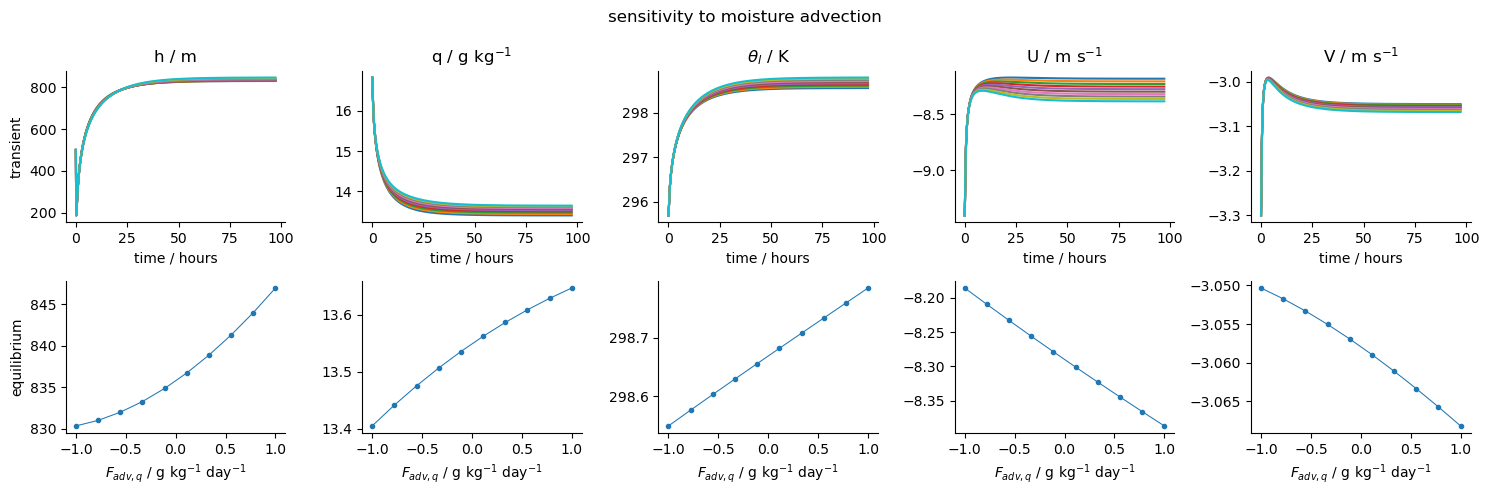

In [35]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle("sensitivity to moisture advection")
ax = ax.flatten()

for i in F_advQ_sens.keys():
    ax[0].plot(F_advQ_sens[i].t/3600, F_advQ_sens[i].y[0])
    ax[1].plot(F_advQ_sens[i].t/3600, 1e3*F_advQ_sens[i].y[1])
    ax[2].plot(F_advQ_sens[i].t/3600, F_advQ_sens[i].y[2])
    ax[3].plot(F_advQ_sens[i].t/3600, F_advQ_sens[i].y[3])
    ax[4].plot(F_advQ_sens[i].t/3600, F_advQ_sens[i].y[4])



ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")



#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in F_advQ_sens.keys():
    h_eq.append(F_advQ_sens[i].y[0][-1])
    q_eq.append(F_advQ_sens[i].y[1][-1]*1e3)
    t_eq.append(F_advQ_sens[i].y[2][-1])
    u_eq.append(F_advQ_sens[i].y[3][-1])
    v_eq.append(F_advQ_sens[i].y[4][-1])

ax[5].plot(F_advQ*86400*1e3, h_eq, ".-", linewidth=0.75)
ax[6].plot(F_advQ*86400*1e3, q_eq, ".-", linewidth=0.75)
ax[7].plot(F_advQ*86400*1e3, t_eq, ".-", linewidth=0.75)  
ax[8].plot(F_advQ*86400*1e3, u_eq, ".-", linewidth=0.75)
ax[9].plot(F_advQ*86400*1e3, v_eq, ".-", linewidth=0.75)



ax[5].set_ylabel("equilibrium")


from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax[7].yaxis.set_major_formatter(formatter)


for x in ax[5:]:
    x.set_xlabel(r"$F_{adv,q}$ / $\rm g~kg^{-1}~day^{-1}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

In [ ]:
F_advTh_sens = {}

for F_th in F_advTh:
    args = (SST_0, D_0_base, q_free_0_base, th_free_0_base, ps_0, f, U_free_0, V_free_0, frac_Ustar, F_advQ_base, F_th, F_rad_base)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
    
    F_advTh_sens[F_th] = sol

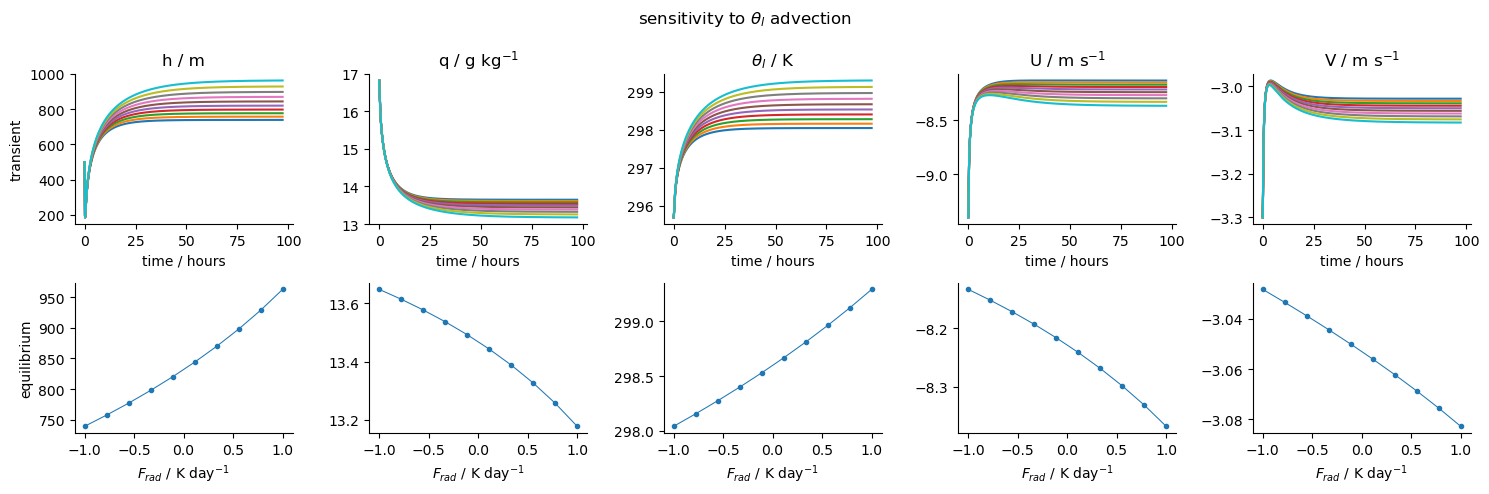

In [17]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle(r"sensitivity to $\theta_l$ advection")
ax = ax.flatten()

for i in F_advTh_sens.keys():
    ax[0].plot(F_advTh_sens[i].t/3600, F_advTh_sens[i].y[0])
    ax[1].plot(F_advTh_sens[i].t/3600, 1e3*F_advTh_sens[i].y[1])
    ax[2].plot(F_advTh_sens[i].t/3600, F_advTh_sens[i].y[2])
    ax[3].plot(F_advTh_sens[i].t/3600, F_advTh_sens[i].y[3])
    ax[4].plot(F_advTh_sens[i].t/3600, F_advTh_sens[i].y[4])



ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")



#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in F_advTh_sens.keys():
    h_eq.append(F_advTh_sens[i].y[0][-1])
    q_eq.append(F_advTh_sens[i].y[1][-1]*1e3)
    t_eq.append(F_advTh_sens[i].y[2][-1])
    u_eq.append(F_advTh_sens[i].y[3][-1])
    v_eq.append(F_advTh_sens[i].y[4][-1])

ax[5].plot(F_advTh*86400, h_eq, ".-", linewidth=0.75)
ax[6].plot(F_advTh*86400, q_eq, ".-", linewidth=0.75)
ax[7].plot(F_advTh*86400, t_eq, ".-", linewidth=0.75)
ax[8].plot(F_advTh*86400, u_eq, ".-", linewidth=0.75)
ax[9].plot(F_advTh*86400, v_eq, ".-", linewidth=0.75)


ax[5].set_ylabel("equilibrium")

for x in ax[5:]:
    x.set_xlabel(r"$F_{rad}$ / $\rm K~day^{-1}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

In [ ]:
F_rad_sens = {}

F_rad   = np.linspace(-3./86400, 0.9/86400, 10)         # K / day


for rad in F_rad:
    args = (SST_0, D_0_base, q_free_0_base, th_free_0_base, ps_0, f, U_free_0, V_free_0, frac_Ustar, F_advQ_base, F_advTh_base, rad)


    ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
    sol = solve_ivp(equations_model, [0,max_t], y0, t_eval = t_eval_eq,\
                        dense_output=True, max_step=dt_max, args=args)
    
    F_rad_sens[rad] = sol

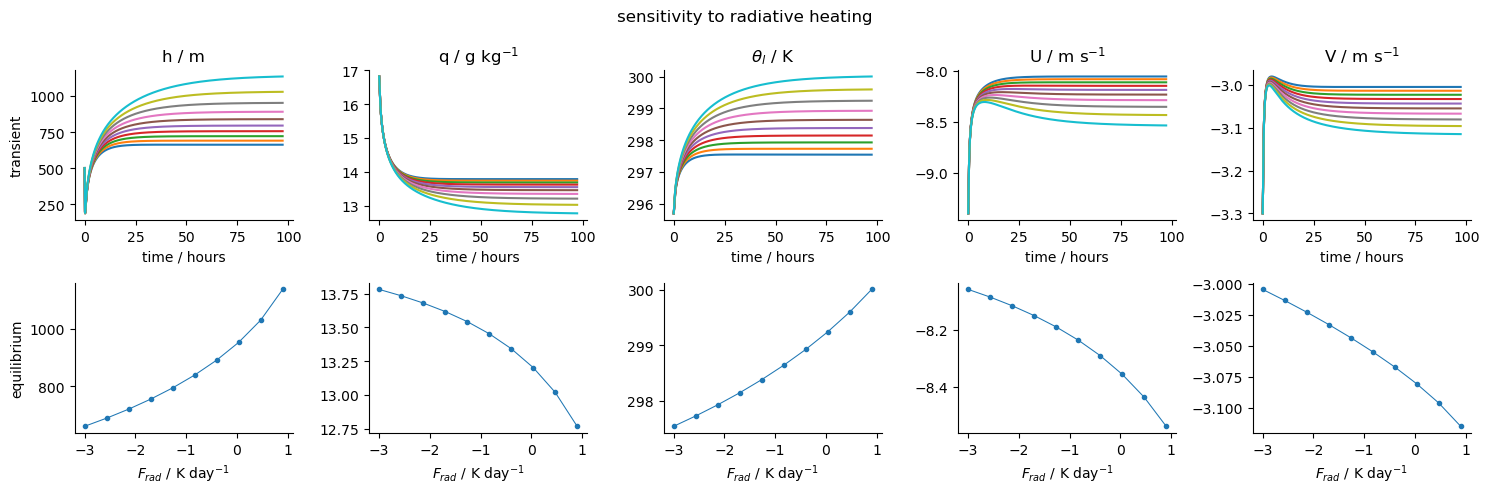

In [21]:
fig, ax = plt.subplots(2,5, figsize=(15,5))
fig.suptitle("sensitivity to radiative heating")
ax = ax.flatten()

for i in F_rad_sens.keys():
    ax[0].plot(F_rad_sens[i].t/3600, F_rad_sens[i].y[0])
    ax[1].plot(F_rad_sens[i].t/3600, 1e3*F_rad_sens[i].y[1])
    ax[2].plot(F_rad_sens[i].t/3600, F_rad_sens[i].y[2])
    ax[3].plot(F_rad_sens[i].t/3600, F_rad_sens[i].y[3])
    ax[4].plot(F_rad_sens[i].t/3600, F_rad_sens[i].y[4])

ax[0].set_title("h / m")
ax[1].set_title(r"q / $\rm g~kg^{-1}$")
ax[2].set_title(r"$\theta_l$ / K")
ax[3].set_title(r"U / $\rm m~s^{-1}$")
ax[4].set_title(r"V / $\rm m~s^{-1}$")


ax[0].set_ylabel("transient")

for x in ax[0:5]:
    x.set_xlabel(r"time / hours")


#################   equilibrium variables   ################
h_eq = []
q_eq = []
t_eq = []
u_eq = []
v_eq = []


for i in F_rad_sens.keys():
    h_eq.append(F_rad_sens[i].y[0][-1])
    q_eq.append(F_rad_sens[i].y[1][-1]*1e3)
    t_eq.append(F_rad_sens[i].y[2][-1])
    u_eq.append(F_rad_sens[i].y[3][-1])
    v_eq.append(F_rad_sens[i].y[4][-1])

ax[5].plot(F_rad*86400, h_eq, ".-", linewidth=0.75)
ax[6].plot(F_rad*86400, q_eq, ".-", linewidth=0.75)
ax[7].plot(F_rad*86400, t_eq, ".-", linewidth=0.75)
ax[8].plot(F_rad*86400, u_eq, ".-", linewidth=0.75)
ax[9].plot(F_rad*86400, v_eq, ".-", linewidth=0.75)

ax[5].set_ylabel("equilibrium")

for x in ax[5:]:
    x.set_xlabel(r"$F_{rad}$ / $\rm K~day^{-1}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

plt.tight_layout()

## Fig. 2: once initial equilibrium is set, modify SST by 1K

### Replying to first reviews 
The forced WRF run has mean values of such variables:
 - SST = 299.8 K
 - D [average between 800-500 hPa ca.] = -4.6e-7 (?)
 - $q^+$ [820 hPa] = 4.6e-3 kg/kg
 - $\theta_l^+$ = 305.16 K
 - $U^+$ , $V^+$ [at 900 hPa] = -9.4 m/s , -3.3 m/s 
 - $F_{adv, Q}$ = -0.6 $g~kg^{-1}~day^{-1}$
 - $F_{adv, \theta}$ = -1.1 $K~day^{-1}$

In [38]:
# Compute the wind components (to be used as free tropospheric wind) starting from the surface wind used in 

U_free = -9.4 # [m/s], free zonal wind (above the ABL).
V_free = -3.3 # [m/s], free meridional wind (above the ABL).

print(U_free)
print(V_free)

Omega = 2*np.pi/86400 # [rad/s] Earth rotation.
latitude0 = 10 # degree N
f = Omega * np.sin(latitude0*np.pi/180)

-9.4
-3.3


In [39]:
(U_free**2 + V_free**2)**0.5

9.962429422585638

In [40]:
#############################   CHOICE OF MODEL EQUATIONS  #################################
equations_model = bulk_model_code.neggers_et_al_2006_stevens_et_al_2002_fracUstar #neggers_stevens.neggers_et_al_2006_stevens_et_al_2002_fracUstar


#######################  set parameters and initial conditions from here on  #####################
frac_Ustar = 0.9

# Initial conditions: y0 = [h(0),q(0),th(0),U(0),V(0)]
cpd  = 1004.67                  # J/K/kg, dry air specific heat at constant pressure
Rd = 287.1                      # J/K/kg, dry air gas constant

####  set initial conditions  ####
 
# Input parameters
SST_0 = 299.8                       #301.4                       # [K], sea surface temperature
D_0 = -4.6e-7                       #4.3e-6                        # [1/s], large scale divergence
q_free_0 = 4.6e-3                   # 4.0e-3                   # [kg/kg] free tropospheric total mixing ratio
ps_0 = 1013                         #1015                         # [hPa], surface pressure
ref_p = 1000                        # [hPa], reference pressure for the potential temperature
th_free_0 = 305.16                  #308                     # [K], free tropospheric liquid virtual potential temperature
th_s = SST_0*(ref_p/ps_0)**(Rd/cpd) # surface liquid water potential temperature, assuming no liquid water at the surface
q_s = bulk_model_code.qsea(SST_0-273.15,ps_0)*1e-3

# adjust initial conditions (boundary layer humidity) depending on SST value!
y0 = [500, q_s - 10e-3, th_s-3, U_free, V_free]  

print(y0)

## set integration times
max_t = 7e5
dt_max = 60
time = [0, max_t]

# apply the perturbation at t_split
factor_time = 0.5;  t_split = factor_time*max_t
t_eval_eq = np.arange(0,t_split,dt_max)


t_eval_pert = np.arange(t_split, max_t, dt_max)


[500, np.float64(0.0118190441680946), 295.69547448881485, -9.4, -3.3]


In [41]:
## I am saving model parameters which ARE NOT solutions to the equations in these external dictionaries
#dict_ext_NS_eq = { 'area_c_ext':[], 'w_star_ext':[], 'M_ext':[], 'E_ext':[],'LHF_ext':[], 'LHF_CC_ext':[],\
#                   'qs_ext':[], 'qsat_ext':[], 'SHF_ext':[], 'LCL_ext':[], 'sigma_q_ext':[], 'we_dyn_ext':[],\
#                   'C_delta_q':[], 'C_delta_th':[], 'q_flux_s':[], 'th_flux_s':[]}

## initial unperturbed arguments ##
args_initial = (SST_0, D_0, q_free_0, th_free_0, ps_0, f, U_free, V_free, frac_Ustar)


###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
sol_NS_eq = solve_ivp(equations_model, [0,t_split], y0, t_eval = t_eval_eq,\
                      dense_output=True, max_step=dt_max, args=args_initial)

y0_split = sol_NS_eq.y[:,-1]

In [42]:
y0_split

array([ 7.30756007e+02,  1.37638137e-02,  2.98061654e+02, -8.17817872e+00,
       -3.02969865e+00])

In [43]:
### COLD PERTURBATION  ####
#########   after reaching equilibrium , cool SST     ##########
SST_cold = SST_0-0.5
args_modif_cold = (SST_cold, D_0, q_free_0, th_free_0, ps_0, f, U_free, V_free, frac_Ustar)

sol_NS_eqPert_cold = solve_ivp(equations_model, [t_split,max_t], y0_split, t_eval = t_eval_pert,\
                               dense_output=True, max_step=dt_max, args=args_modif_cold)



In [44]:
### WARM PERTURBATION  ####
#########   after reaching equilibrium , warm SST     ##########
SST_warm = SST_0+0.5
args_modif_warm = (SST_warm, D_0, q_free_0, th_free_0, ps_0, f, U_free, V_free, frac_Ustar)


sol_NS_eqPert_warm = solve_ivp(equations_model, [t_split,max_t], y0_split, t_eval = t_eval_pert,\
                               dense_output=True, max_step=dt_max, args=args_modif_warm)

In [45]:
### store solutions

h_eq, h_cold, h_warm    =  sol_NS_eq.y[0], sol_NS_eqPert_cold.y[0], sol_NS_eqPert_warm.y[0]   ##  y_combined[0]
q_eq, q_cold, q_warm    =  sol_NS_eq.y[1], sol_NS_eqPert_cold.y[1], sol_NS_eqPert_warm.y[1]   #y_combined[1]
th_eq, th_cold, th_warm =  sol_NS_eq.y[2], sol_NS_eqPert_cold.y[2], sol_NS_eqPert_warm.y[2]   #y_combined[2]
U_eq, U_cold, U_warm    =  sol_NS_eq.y[3], sol_NS_eqPert_cold.y[3], sol_NS_eqPert_warm.y[3]   #y_combined[3]
V_eq, V_cold, V_warm    =  sol_NS_eq.y[4], sol_NS_eqPert_cold.y[4], sol_NS_eqPert_warm.y[4]   #y_combined[4]

# compute diagnostics at the same integration timesteps as the prognostic variables
diagnostics_eq   = bulk_model_code.compute_diagnostics(sol_NS_eq.y, SST_0, ps_0, q_free_0, th_free_0, frac_Ustar)
diagnostics_cold = bulk_model_code.compute_diagnostics(sol_NS_eqPert_cold.y, SST_cold, ps_0, q_free_0, th_free_0, frac_Ustar)
diagnostics_warm = bulk_model_code.compute_diagnostics(sol_NS_eqPert_warm.y, SST_warm, ps_0, q_free_0, th_free_0, frac_Ustar)



# Define a time axis for the variables that are not retrieved as standard output of the models.
'''t_final_NS_eq, t_final_NS_cold, t_final_NS_warm = np.max(sol_NS_eq.t),\
                                                  np.max(sol_NS_eqPert_cold.t),\
                                                  np.max(sol_NS_eqPert_warm.t)

dt_NS_eq, dt_NS_cold, dt_NS_warm = t_final_NS_eq   / len(dict_ext_NS_eq['E_ext']),\
                                   (t_final_NS_cold - t_final_NS_eq) / len(dict_ext_NS_eqPert_cold['E_ext']),\
                                   (t_final_NS_warm - t_final_NS_eq) / len(dict_ext_NS_eqPert_warm['E_ext']) # [h]'''

#time_ext_NS_eq   = np.arange(len(dict_ext_NS_eq['E_ext']))* dt_NS_eq
#time_ext_NS_cold = np.arange(len(dict_ext_NS_eqPert_cold['E_ext']), len(dict_ext_NS_eqPert_cold['E_ext']) / factor_time) * dt_NS_cold
#time_ext_NS_warm = np.arange(len(dict_ext_NS_eqPert_warm['E_ext']), len(dict_ext_NS_eqPert_warm['E_ext']) / factor_time) * dt_NS_warm

# print('equilibrium h = '+str(h[-1])+' m')
# print('equilibrium q = '+str(q[-1]*1e3)+' g/kg')
# print('equilibrium th = ' +str(th[-1])+' K')
# print('equilibrium a$_c$ = '+str(dict_ext_NS_eqPert['area_c_ext'][-1]*100)+'%')
# print('equilibrium w$^*$ = '+str(dict_ext_NS_eqPert['w_star_ext'][-1])+' m/s')

"t_final_NS_eq, t_final_NS_cold, t_final_NS_warm = np.max(sol_NS_eq.t),                                                  np.max(sol_NS_eqPert_cold.t),                                                  np.max(sol_NS_eqPert_warm.t)\n\ndt_NS_eq, dt_NS_cold, dt_NS_warm = t_final_NS_eq   / len(dict_ext_NS_eq['E_ext']),                                   (t_final_NS_cold - t_final_NS_eq) / len(dict_ext_NS_eqPert_cold['E_ext']),                                   (t_final_NS_warm - t_final_NS_eq) / len(dict_ext_NS_eqPert_warm['E_ext']) # [h]"

In [46]:

# Organize variables in a dictionary
data = {
    "h": {"eq": h_eq, "cold": h_cold, "warm": h_warm},
    "q": {"eq": q_eq*1e3, "cold": q_cold*1e3, "warm": q_warm*1e3},
    "th": {"eq": th_eq, "cold": th_cold, "warm": th_warm},
    "U": {"eq": U_eq, "cold": U_cold, "warm": U_warm},
    "V": {"eq": V_eq, "cold": V_cold, "warm": V_warm},
}

# Build table using last element [-1]
rows = {}

for var, values in data.items():
    eq_last = values["eq"][-1]
    cold_last = values["cold"][-1]
    warm_last = values["warm"][-1]
    
    rows[var] = {
        "eq": eq_last,
        "cold": cold_last,
        "warm": warm_last,
        "cold pert": cold_last - eq_last,
        "warm pert": warm_last - eq_last,
    }

df = pd.DataFrame.from_dict(rows, orient="index")

df

,eq,cold,warm,cold pert,warm pert
h,730.756007,607.669217,857.701142,-123.086791,126.945135
q,13.763814,14.303002,13.227650,0.539189,-0.536164
th,298.061654,297.653142,298.466495,-0.408513,0.404840
U,-8.178179,-7.951284,-8.358910,0.226895,-0.180731
V,-3.029699,-2.981754,-3.067067,0.047945,-0.037368


In [47]:
#(h_warm[-1] - diagnostics_warm['LCL'][-1]) - (h_cold[-1] - diagnostics_cold['LCL'][-1])
#q_warm[-1] - diagnostics_warm['qsat'][-1]

g = 9.81
Rd = 287.1
cpd = 1004.67
ps = 1015

T0 = th_eq*(ps/ref_p)**(Rd/cpd) 

T_lcl = T0-(g/cpd)*diagnostics_cold["LCL"]                                           # [K], air temperature at h following a dry adiabat.
p_lcl = ps*100*(1-g*diagnostics_cold["LCL"]  /(T0*cpd))**(cpd/Rd)  # [Pa], air pressure at h with p=rho*R*T; dp/dz=-rho*g; dtheta/dz=0 
e_sat_lcl = bulk_model_code.qsat(T_lcl-273.15,p_lcl/100)*100                                              # [Pa], saturation vapor pressure at h.
q_sat_lcl = 0.622*e_sat_lcl/(p_lcl-0.378*e_sat_lcl) 


q_cold[-1] - q_sat_lcl[-1]

np.float64(-0.0003625182891540367)

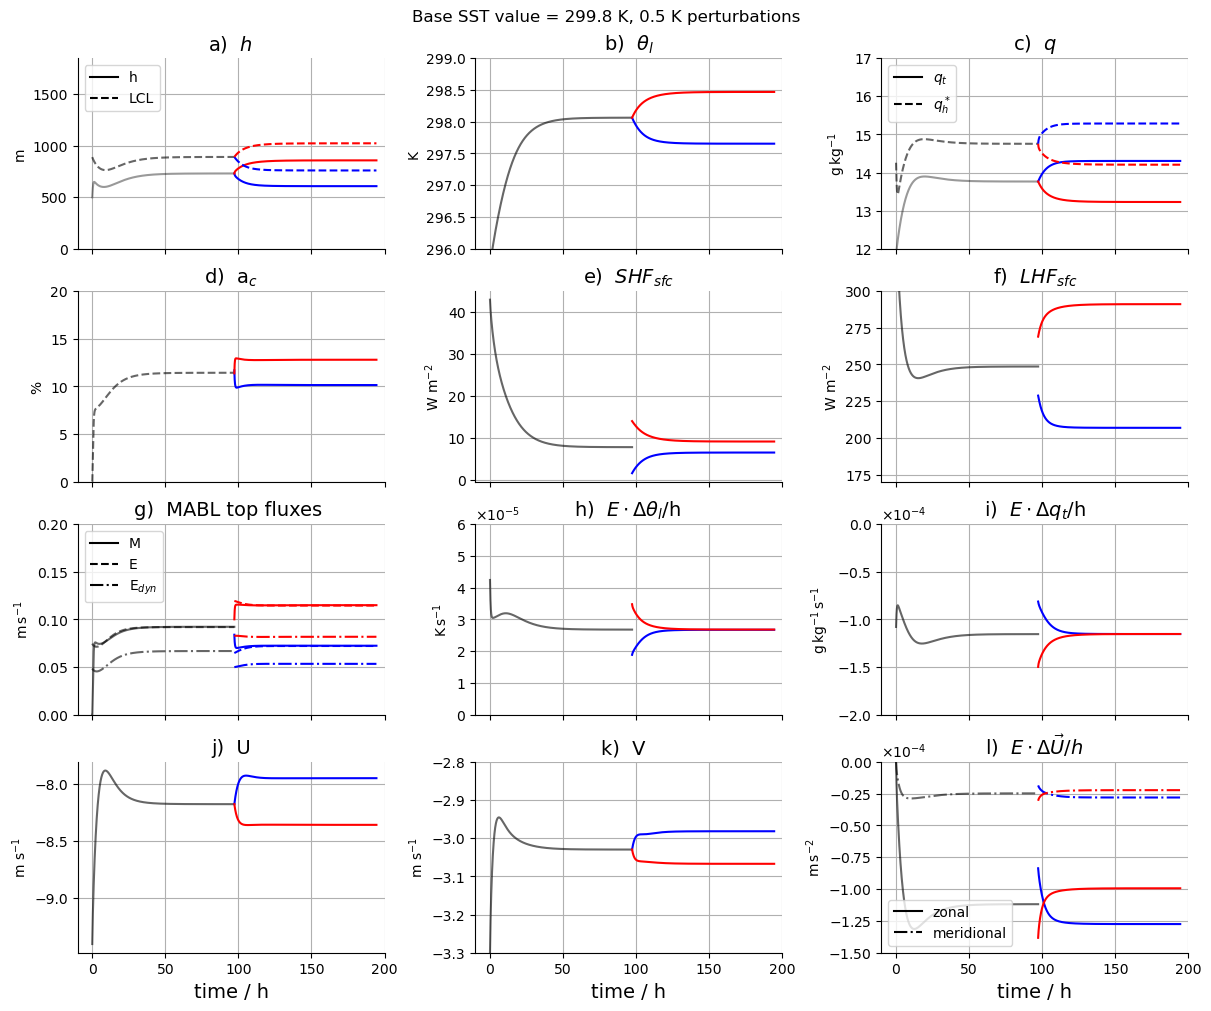

In [48]:
fig, ax = plt.subplots(4,3,figsize=(12,10),sharex=True,constrained_layout=True)
fig.suptitle(f'Base SST value = {SST_0} K, 0.5 K perturbations')
import matplotlib.lines as mlines
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))  # Use scientific notation outside the range [10^-2, 10^2]



#################  h and LCL  ##################
solid_line = mlines.Line2D([], [], color='k', label='h', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label='LCL', linestyle='--')
ax[0,0].plot(sol_NS_eq.t/3600,h_eq,'k', alpha=0.4)
ax[0,0].plot(sol_NS_eqPert_cold.t/3600,h_cold,'b')
ax[0,0].plot(sol_NS_eqPert_warm.t/3600,h_warm,'r')
## LCL ##
ax[0,0].plot(sol_NS_eq.t/3600,          diagnostics_eq['LCL'],  '--k', alpha=0.6)
ax[0,0].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['LCL'],'--b')
ax[0,0].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['LCL'],'--r')
ax[0,0].set_title(r'a)  $h$ ',fontsize=14)
ax[0,0].set_ylim(0,1.85e3)
ax[0,0].grid()
ax[0,0].legend(handles=[solid_line, dashed_line], loc='upper left')
ax[0,0].set_ylabel(r"m")


##### temperature  ######
ax[0,1].plot(sol_NS_eq.t/3600,th_eq,'k', label='EQ', alpha=0.6)
ax[0,1].plot(sol_NS_eqPert_cold.t/3600,th_cold,'blue', label='COLD')
ax[0,1].plot(sol_NS_eqPert_warm.t/3600,th_warm,'r', label='WARM')
ax[0,1].set_title(r'b)  $\theta_l$',fontsize=14)
ax[0,1].set_ylim(296,299)
ax[0,1].grid()
ax[0,1].set_ylabel("K")


############## moisture  ##########
solid_line = mlines.Line2D([], [], color='k', label=r'$q_{t}$', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label=r'$q^*_{h}$', linestyle='--')

ax[0,2].plot(sol_NS_eq.t/3600,q_eq*1e3,'k', alpha=0.4)
ax[0,2].plot(sol_NS_eqPert_cold.t/3600,q_cold*1e3,'blue')
ax[0,2].plot(sol_NS_eqPert_warm.t/3600,q_warm*1e3,'r')

ax[0,2].plot(sol_NS_eq.t/3600,          diagnostics_eq['qsat']*1e3,'--k', alpha=0.6)
ax[0,2].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['qsat']*1e3,'--b')
ax[0,2].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['qsat']*1e3,'--r')
ax[0,2].set_title(r'c)  $q$',fontsize=14)
ax[0,2].set_ylim(12,17)
ax[0,2].grid()
ax[0,2].legend(handles=[solid_line, dashed_line], loc='upper left')
ax[0,2].set_ylabel(r"$\rm g\,kg^{-1}$")




#####  second row

######  a_c  ######
ax[1,0].plot(sol_NS_eq.t/3600,          diagnostics_eq['area_c']*100,'--k', label='ac_eq',  alpha=0.6)
ax[1,0].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['area_c']*100,'b', label='ac_cold')
ax[1,0].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['area_c']*100,'r', label='ac_warm')
ax[1,0].set_title('d)  a$_c$',fontsize=14)
ax[1,0].set_ylim(0,20)
ax[1,0].grid()
ax[1,0].set_ylabel("%")


######  SHF  #####
ax[1,1].plot(sol_NS_eq.t/3600,          diagnostics_eq['SHF'],'k', label='SHF_eq',  alpha=0.6)
ax[1,1].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['SHF'],'b', label='SHF_cold')
ax[1,1].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['SHF'],'r', label='SHF_warm')
ax[1,1].set_title(r'e)  $SHF_{sfc}$',fontsize=14)
ax[1,1].grid()
ax[1,1].set_ylabel(r"$\rm W~m^{-2}$")


######  LHF  #####
solid_line = mlines.Line2D([], [], color='k', label='LHF', linestyle='-')
# dashed_line = mlines.Line2D([], [], color='k', label='LHF CC', linestyle='--')
ax[1,2].plot(sol_NS_eq.t/3600,          diagnostics_eq['LHF'],'k', label='LHF_eq',  alpha=0.6)
ax[1,2].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['LHF'],'b', label='LHF_cold')
ax[1,2].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['LHF'],'r', label='LHF_warm')

'''ax[1,2].plot(sol_NS_eq.t/3600,          diagnostics_eq['LHF_CC'],'--k', label='LHF CC eq',  alpha=0.6)
ax[1,2].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['LHF_CC'],'--b', label='LHF CC cold')
ax[1,2].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['LHF_CC'],'--r', label='LHF CC warm')'''
ax[1,2].set_title(r'f)  $LHF_{sfc}$',fontsize=14)
ax[1,2].grid()
ax[1,2].set_ylim(170,300)
# ax[1,2].legend(handles=[solid_line], loc='center left')
ax[1,2].set_ylabel(r"$\rm W~m^{-2}$")





#### third row  ##


######### MABL top fluxes  ############
# Create custom legend handles for solid and dashed lines
solid_line  = mlines.Line2D([], [], color='k', label='M', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label='E', linestyle='--')
dash_dot    = mlines.Line2D([], [], color='k', label=r'E$_{dyn}$', linestyle='-.')

ax[2,0].plot(sol_NS_eq.t/3600,          diagnostics_eq['M'],'k', label='M_eq',  alpha=0.6)
ax[2,0].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['M'],'b', label='M_cold')
ax[2,0].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['M'],'r', label='M_warm')

ax[2,0].plot(sol_NS_eq.t/3600,          diagnostics_eq['E'],'--k', label='E_eq',  alpha=0.6)
ax[2,0].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['E'],'--b', label='E_cold')
ax[2,0].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['E'],'--r', label='E_warm')

ax[2,0].plot(sol_NS_eq.t/3600,          diagnostics_eq['we_dyn'],'-.k', label='we_eq',  alpha=0.6)
ax[2,0].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['we_dyn'],'-.b', label='we_cold')
ax[2,0].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['we_dyn'],'-.r', label='we_warm')

ax[2,0].set_ylim(0,0.2)
ax[2,0].grid()
ax[2,0].legend(handles=[solid_line, dashed_line, dash_dot], loc='upper left')
ax[2,0].set_title(r'g)  MABL top fluxes ',fontsize=14)
ax[2,0].set_ylabel(r"$\rm m\,s^{-1}$")


### theta entrainment
#indices = np.abs(time_ext_NS_eq[:, None] - t_eval_eq).argmin(axis=0)

ax[2,1].plot(sol_NS_eq.t/3600,          diagnostics_eq['E']*diagnostics_eq['C_delta_th']/h_eq,'k', label='E_eq', alpha=0.6)
ax[2,1].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['E']*diagnostics_cold['C_delta_th']/h_cold,'b', label='E_cold')
ax[2,1].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['E']*diagnostics_warm['C_delta_th']/h_warm,'r', label='E_warm')
ax[2,1].grid()
ax[2,1].set_title(r'h)  $E\cdot\Delta \theta_l$/h ',fontsize=14)
ax[2,1].set_ylim([0, 6e-5])
formatter_2 = ticker.ScalarFormatter(useMathText=True)
formatter_2.set_scientific(True)
formatter_2.set_powerlimits((0, 0))  # Use scientific notation outside the range [10^-2, 10^2]

ax[2,1].yaxis.set_major_formatter(formatter_2)
ax[2,1].set_ylabel(r"$\rm K\,s^{-1}$")




### q entrainment
ax[2,2].plot(sol_NS_eq.t/3600,          1000*diagnostics_eq['E']*diagnostics_eq['C_delta_q']/h_eq,'k', label='E_eq', alpha=0.6)
ax[2,2].plot(sol_NS_eqPert_cold.t/3600, 1000*diagnostics_cold['E']*diagnostics_cold['C_delta_q']/h_cold,'b', label='E_cold')
ax[2,2].plot(sol_NS_eqPert_warm.t/3600, 1000*diagnostics_warm['E']*diagnostics_warm['C_delta_q']/h_warm,'r', label='E_warm')
ax[2,2].grid()
ax[2,2].set_title(r'i)  $E\cdot\Delta q_t$/h',fontsize=14)
ax[2,2].set_ylim([-0.0002, 0])
ax[2,2].yaxis.set_major_formatter(formatter)
ax[2,2].ticklabel_format(axis='y', style='sci')
ax[2,2].set_ylabel(r"$\rm g\,kg^{-1}\,s^{-1}$")




#### fourth row  ###


#######  wind  ######
# ax[3,0].hlines(U_free,np.min(sol_NS_eq.t/3600),np.max(sol_NS_eq.t/3600),'k',linestyle='dashed')
ax[3,0].plot(sol_NS_eq.t/3600, U_eq, 'k',  alpha=0.6)
ax[3,0].plot(sol_NS_eqPert_cold.t/3600, U_cold,'blue')
ax[3,0].plot(sol_NS_eqPert_warm.t/3600, U_warm,'r')
ax[3,0].set_title(r'j)  U',fontsize=14)
# ax[3,0].set_ylim(-8,-5.8)
ax[3,0].grid()
ax[3,0].set_ylabel(r"$\rm m~s^{-1}$")

# ax[3,1].hlines(V_free,np.min(sol_NS_eq.t/3600),np.max(sol_NS_eq.t/3600),'k',linestyle='dashed')
ax[3,1].plot(sol_NS_eq.t/3600, V_eq, 'k',  alpha=0.6)
ax[3,1].plot(sol_NS_eqPert_cold.t/3600, V_cold,'blue')
ax[3,1].plot(sol_NS_eqPert_warm.t/3600, V_warm,'r')
ax[3,1].set_title(r'k)  V  ',fontsize=14)
ax[3,1].set_ylim(-3.3,-2.8)
ax[3,1].grid()
ax[3,1].set_ylabel(r"$\rm m~s^{-1}$")


### wind entrainment 
solid_line  = mlines.Line2D([], [], color='k', label=r'zonal', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label=r'meridional', linestyle='-.')
ax[3,2].plot(sol_NS_eq.t/3600,          diagnostics_eq['we_dyn']*(U_free-U_eq)/h_eq,'k', label='we_eq',  alpha=0.6)
ax[3,2].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['we_dyn']*(U_free-U_cold)/h_cold,'b', label='we_cold')
ax[3,2].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['we_dyn']*(U_free-U_warm)/h_warm,'r', label='we_warm')

ax[3,2].plot(sol_NS_eq.t/3600,          diagnostics_eq['we_dyn']*(V_free-V_eq)/h_eq,'-.k', label='we_eq',  alpha=0.6)
ax[3,2].plot(sol_NS_eqPert_cold.t/3600, diagnostics_cold['we_dyn']*(V_free-V_cold)/h_cold,'-.b', label='we_cold')
ax[3,2].plot(sol_NS_eqPert_warm.t/3600, diagnostics_warm['we_dyn']*(V_free-V_warm)/h_warm,'-.r', label='we_warm')
ax[3,2].legend(handles=[solid_line, dashed_line], loc='lower left')
ax[3,2].set_title(r'l)  $E\cdot \Delta \vec{U} / h $ ',fontsize=14)
ax[3,2].set_ylim([-0.00015, 0])
ax[3,2].grid()
ax[3,2].set_ylabel(r"$\rm m\,s^{-2}$")

ax[3,2].yaxis.set_major_formatter(formatter)
ax[3,2].ticklabel_format(axis='y', style='sci')


ax[3,0].set_xlabel('time / h',fontsize=14)
ax[3,1].set_xlabel('time / h',fontsize=14)
ax[3,2].set_xlabel('time / h',fontsize=14)
ax[3,0].set_xlim(-10,200)
ax[3,1].set_xlim(-10,200)
ax[3,2].set_xlim(-10,200)


for x in ax.flatten():
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)


# plt.savefig("/work/mh1498/m301248/TCO_data/QJRMS_0316/bulk_base_run_rev.pdf", dpi=300)

## Feb '26 : material for reviews
Analitically estimate the adjustment timescales of variables

In [49]:
def set_variables_for_fit(var):
    if var in diagnostics_eq.keys():
        var_values_warm = np.array(diagnostics_warm[var][2:])
        var_values_cold = np.array(diagnostics_cold[var][2:])

        time_warm, time_cold = sol_NS_eqPert_warm.t[2:]/3600, sol_NS_eqPert_cold.t[2:]/3600
    else:
        time_warm = sol_NS_eqPert_cold.t/3600; time_cold = sol_NS_eqPert_cold.t/3600
        if var == 'h':
            var_values_warm = h_warm; var_values_cold = h_cold
        if var == 'th':
            var_values_warm = th_warm; var_values_cold = th_cold
        if var == 'q':
            var_values_warm = q_warm; var_values_cold = q_cold
        if var == 'U':
            var_values_warm = U_warm; var_values_cold = U_cold
        if var == 'V':
            var_values_warm = V_warm; var_values_cold = V_cold

        if var == 'U_tot':
            var_values_warm = (U_warm**2 + V_warm**2)**0.5 ; var_values_cold = (U_cold**2 + V_cold**2)**0.5
            
    return time_warm, time_cold, var_values_warm, var_values_cold

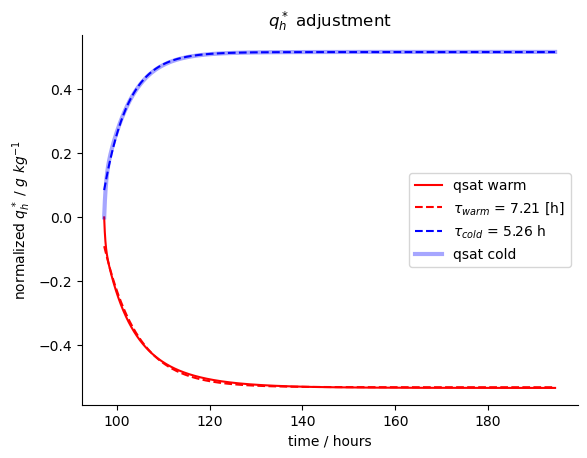

In [50]:

var = 'qsat' 
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c):  # "warm"
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def double_exp(x, a, b, c, d, f, g, h):  
    return a+b*np.exp(c*(x-d)) + f*np.exp(g*(x-h))

def increasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_exp(x, a, b, c):  # "cold"
    return a*np.exp(b*(x-c))


'''
x, y = time_warm, var_values_warm
y = y - np.min(y)
y = y*1e3

initial_guess = [y[-1], 0., -1/5, 130, -y[-1]+y[0], -1/50, y[0]]   #[y[-1], -1/50, 100, y[-1]-y[0], -1/20, 120]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(double_exp, x, y, p0=initial_guess, maxfev=6000)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])
a, b, c, d, f, g, h = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2], fit_params_warm[3], fit_params_warm[4], fit_params_warm[5], fit_params_warm[6]
plt.plot(x, double_exp(x, a, b, c, d, f, g, h), '--r', label=r'$\tau_{decay}$ ='+f' {np.abs(round(1/c,2))} [h]') #+r'\n $\tau_{decay}$ = '+f'{np.abs(round(1/g,2))} [h]' )

plt.plot(x, y, 'r', label=f'{var} warm', alpha=0.35, linewidth=3)

x, y = time_cold, var_values_cold
y = y - np.min(y)
y = y*1e3
initial_guess = [y[-1], 0, -1/5, x[0], (np.max(y)-y[-1]), -1/50, 115]  #[y[-1], -1/2, 100, np.max(y)-y[-1], -1/15, 110]

# Fit the data to the exponential model

fit_params_cold, params_covar_cold = curve_fit(double_exp, x, y, p0=initial_guess, maxfev=6000)
a, b, c, d, f, g, h = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2], fit_params_cold[3], fit_params_cold[4], fit_params_cold[5], fit_params_cold[6]
plt.plot(x, double_exp(x, a, b, c, d, f, g, h), '--b', label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')

plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)'''



x, y = time_warm, var_values_warm
y = y - y[0] #np.min(y)
y = y*1e3
initial_guess = [y[-1], -1/10, 100]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
plt.plot(x, y, 'r', label=f'{var} warm')
plt.plot(x, increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')




x, y = time_cold, var_values_cold
y = y - y[0] #np.min(y)
y = y*1e3

#initial_guess = [y[-1], 0, -1/10, x[0], (np.max(y)-y[-1]), -1/50, 115]  #[y[-1], -1/2, 100, np.max(y)-y[-1], -1/15, 110]

# Fit the data to the exponential model

initial_guess = [y[-1], -1/20, 100]

# Fit the data to the exponential model
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)

'''fit_params_cold, params_covar_cold = curve_fit(double_exp, x, y, p0=initial_guess, maxfev=6000)
a, b, c, d, f, g, h = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2], fit_params_cold[3], fit_params_cold[4], fit_params_cold[5], fit_params_cold[6]
plt.plot(x, double_exp(x, a, b, c, d, f, g, h), '--b', label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
'''
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2]
plt.plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ = '+f"{np.abs(1/b):.2f} h") #label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)



         
plt.title(r'$q^*_h$ adjustment')
plt.xlabel("time / hours")
plt.ylabel(r"normalized $q^*_h$ / $g~kg^{-1}$")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
plt.legend(loc='center right')

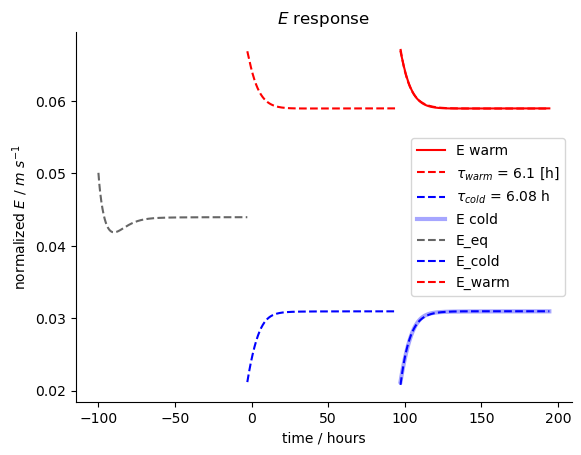

In [15]:

var = 'E' 
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c):  # "warm"
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def double_exp(x, a, b, c, d, f, g, h):  
    return a+b*np.exp(c*(x-d)) + f*np.exp(g*(x-h))

def increasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_exp(x, a, b, c):  # "cold"
    return a*np.exp(b*(x-c))

x, y = time_warm, var_values_warm
y_fit = y - y[0] #np.min(y)
initial_guess = [y[-1], -1/10, x[0]]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y_fit, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
plt.plot(x, y, 'r', label=f'{var} warm')
plt.plot(x, y[0]+increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')


x, y = time_cold, var_values_cold
y = y #- y[0] #np.min(y)

initial_guess = [y[-1], -1/20, x[0]]

# Fit the data to the exponential model
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2]
plt.plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ = '+f"{np.abs(1/b):.2f} h") #label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)



plt.plot(sol_NS_eq.t/3600   - 100.,          diagnostics_eq['E'],'--k', label='E_eq',  alpha=0.6)
plt.plot(sol_NS_eqPert_cold.t/3600 - 100., diagnostics_cold['E'],'--b', label='E_cold')
plt.plot(sol_NS_eqPert_warm.t/3600 - 100., diagnostics_warm['E'],'--r', label='E_warm')

         
plt.title(r'$E$ response')
plt.xlabel("time / hours")
plt.ylabel(r"normalized $E$ / $m~s^{-1}$")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
plt.legend(loc='center right')

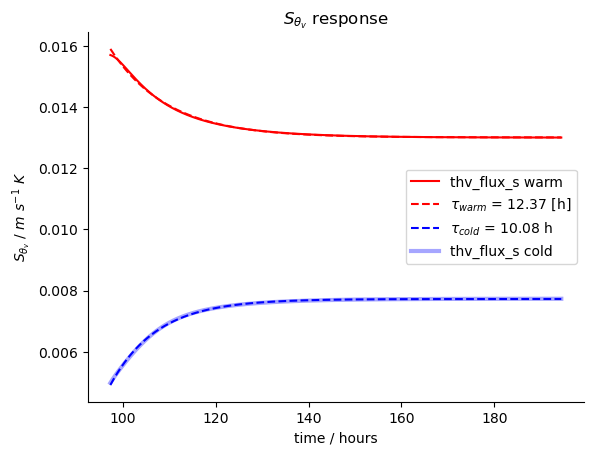

In [16]:

var = 'thv_flux_s'
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c):  # "warm"
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def double_exp(x, a, b, c, d, f, g, h):  
    return a+b*np.exp(c*(x-d)) + f*np.exp(g*(x-h))

def increasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_exp(x, a, b, c):  # "cold"
    return a*np.exp(b*(x-c))

x, y = time_warm, var_values_warm
y_fit = y - y[0] #np.min(y)
initial_guess = [y[-1], -1/20, x[0]]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y_fit, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
plt.plot(x, y, 'r', label=f'{var} warm')
plt.plot(x, y[0]+increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')


x, y = time_cold, var_values_cold
y = y #- y[0] #np.min(y)

initial_guess = [y[-1], -1/20, x[0]]

# Fit the data to the exponential model
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2]
plt.plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ = '+f"{np.abs(1/b):.2f} h") #label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)

'''
plt.plot(sol_NS_eq.t/3600   - 100.,          diagnostics_eq['E'],'--k', label='E_eq',  alpha=0.6)
plt.plot(sol_NS_eqPert_cold.t/3600 - 100., diagnostics_cold['E'],'--b', label='E_cold')
plt.plot(sol_NS_eqPert_warm.t/3600 - 100., diagnostics_warm['E'],'--r', label='E_warm')'''

         
plt.title(r'$S_{\theta_v}$ response')
plt.xlabel("time / hours")
plt.ylabel(r"$S_{\theta_v}$ / $m~s^{-1}~K$")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
plt.legend(loc='center right')

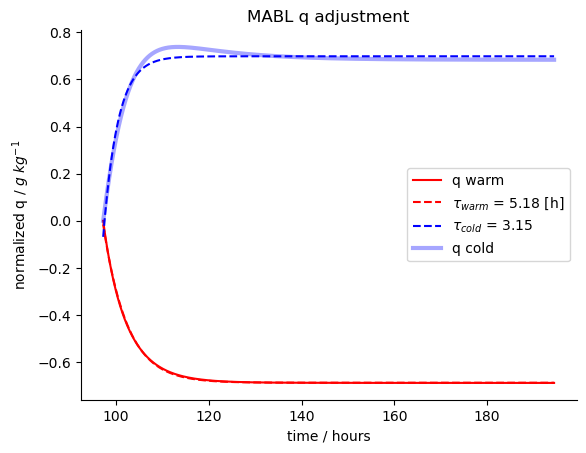

In [17]:

var = 'q' 
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

def compute_derivative(x, field):
    derivative = np.zeros_like(field)
    derivative[0]    = (field[1]-field[0])/(x[1]-x[0])
    derivative[1:-1] = (field[2:]-field[0:-2])/((x[2:]-x[0:-2]))
    derivative[-1]   = (field[-1]-field[-2])/(x[-1]-x[-2])
    return derivative

from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c):  # "warm"
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def increasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_exp(x, a, b, c):  # "cold"
    return a*np.exp(b*(x-c))

def double_exp(x, a, b, c, d, f, g, h):  
    return a+b*np.exp(c*(x-d)) + f*np.exp(g*(x-h))



x, y = time_warm, var_values_warm
y = y - y[0] #np.min(y)
y = y*1e3
initial_guess = [y[-1], -1/10, 100]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
plt.plot(x, y, 'r', label=f'{var} warm')
plt.plot(x, increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')






x, y = time_cold, var_values_cold
y = y - y[0] #np.min(y)
y = y*1e3

#initial_guess = [y[-1], 0, -1/10, x[0], (np.max(y)-y[-1]), -1/50, 115]  #[y[-1], -1/2, 100, np.max(y)-y[-1], -1/15, 110]

# Fit the data to the exponential model

initial_guess = [y[-1], -1/20, 100]

# Fit the data to the exponential model
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)

'''fit_params_cold, params_covar_cold = curve_fit(double_exp, x, y, p0=initial_guess, maxfev=6000)
a, b, c, d, f, g, h = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2], fit_params_cold[3], fit_params_cold[4], fit_params_cold[5], fit_params_cold[6]
plt.plot(x, double_exp(x, a, b, c, d, f, g, h), '--b', label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
'''
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2]
plt.plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ = '+f"{np.abs(1/b):.2f}") #label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)



plt.title(r'MABL q adjustment')
plt.xlabel("time / hours")
plt.ylabel(r"normalized q / $g~kg^{-1}$")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
plt.legend()

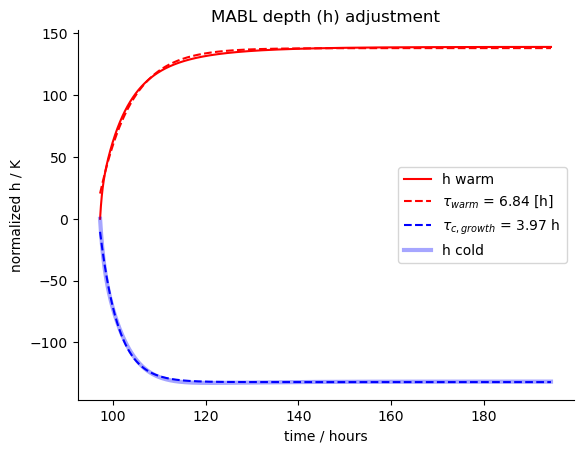

In [18]:

var = 'h'
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

def compute_derivative(x, field):
    derivative = np.zeros_like(field)
    derivative[0]    = (field[1]-field[0])/(x[1]-x[0])
    derivative[1:-1] = (field[2:]-field[0:-2])/((x[2:]-x[0:-2]))
    derivative[-1]   = (field[-1]-field[-2])/(x[-1]-x[-2])
    return derivative

from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c): 
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def increasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_exp(x, a, b, c): 
    return a*np.exp(b*(x-c))


x, y = time_warm, var_values_warm
y = y - y[0]  #np.min(y)
initial_guess = [y[-1], -1/20, x[0]]
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
plt.plot(x, y, 'r', label=f'{var} warm')
plt.plot(x, increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')






x, y = time_cold, var_values_cold
y = y - y[0]  #np.min(y)
initial_guess = [y[-1], -1/20, x[0]]
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2] #, fit_params[3]
plt.plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/b,2))} h')
plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)


plt.title(r'MABL depth (h) adjustment')
plt.xlabel("time / hours")
plt.ylabel(r"normalized h / K")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
plt.legend()

In [20]:
SST_cold

299.9

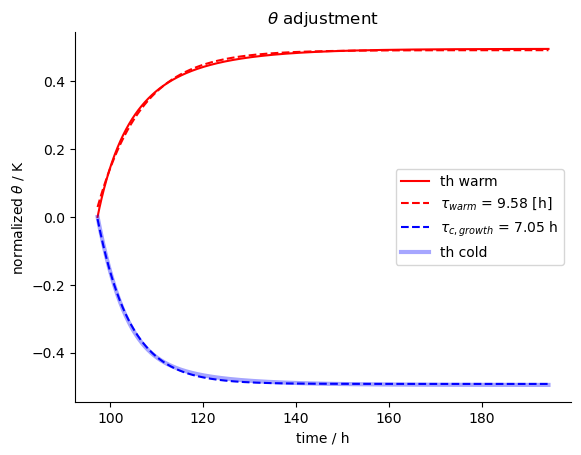

In [21]:

var = 'th'
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

def compute_derivative(x, field):
    derivative = np.zeros_like(field)
    derivative[0]    = (field[1]-field[0])/(x[1]-x[0])
    derivative[1:-1] = (field[2:]-field[0:-2])/((x[2:]-x[0:-2]))
    derivative[-1]   = (field[-1]-field[-2])/(x[-1]-x[-2])
    return derivative

from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c): 
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def increasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_exp(x, a, b, c): 
    return a*np.exp(b*(x-c))


x, y = time_warm, var_values_warm
y = y - y[0]  #np.min(y)
initial_guess = [y[-1], -1/20, 100]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
plt.plot(x, y, 'r', label=f'{var} warm')
plt.plot(x, increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')






x, y = time_cold, var_values_cold
y = y - y[0]  #np.min(y)

initial_guess = [y[-1], -1/20, x[0]]
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2] #, fit_params[3]
plt.plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/b,2))} h')
plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)


plt.title(r'$\theta$ adjustment')
plt.xlabel("time / h")
plt.ylabel(r"normalized $\theta$ / K")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.legend()

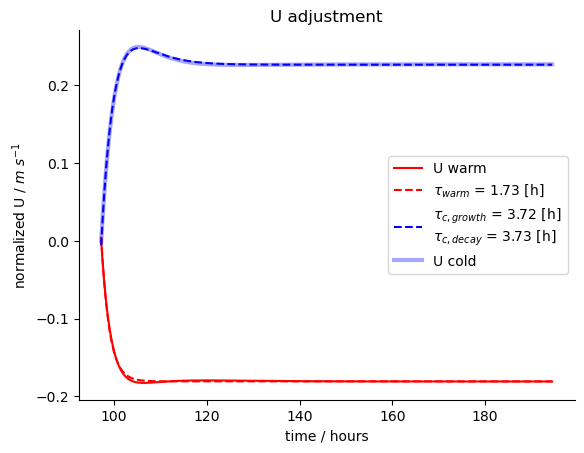

In [28]:

var = 'U' 
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

def compute_derivative(x, field):
    derivative = np.zeros_like(field)
    derivative[0]    = (field[1]-field[0])/(x[1]-x[0])
    derivative[1:-1] = (field[2:]-field[0:-2])/((x[2:]-x[0:-2]))
    derivative[-1]   = (field[-1]-field[-2])/(x[-1]-x[-2])
    return derivative

from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c): 
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def increasing_double_exp(x, a, b, c, d, f, g, h):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g) + h)

def decreasing_exp(x, a, b, c): 
    return a*np.exp(b*(x-c))

def double_exp(x, a, b, c, d, f, g, h):  
    return a+b*np.exp(c*(x-d)) + f*np.exp(g*(x-h))


x, y = time_warm, var_values_warm
y = y - y[0] #np.min(y)
initial_guess = [y[-1], -1/20, 100]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
plt.plot(x, y, 'r', label=f'{var} warm')
plt.plot(x,increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')






x, y = time_cold, var_values_cold
y = y - y[0] #np.min(y)

initial_guess = [y[-1], -y[-1], -1/5, x[0], (np.max(y)-y[-1]), -1/50, x[10]]  #[y[-1], -1/2, 100, np.max(y)-y[-1], -1/15, 110]

# Fit the data to the exponential model

fit_params_cold, params_covar_cold = curve_fit(double_exp, x, y, p0=initial_guess, method="trf", maxfev=6000)
a, b, c, d, f, g, h = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2], fit_params_cold[3], fit_params_cold[4], fit_params_cold[5], fit_params_cold[6]
plt.plot(x, double_exp(x, a, b, c, d, f, g, h), '--b', label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')

plt.plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)



plt.title(r'U adjustment')
plt.xlabel("time / hours")
plt.ylabel(r"normalized U / $m~s^{-1}$")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.legend()

#### big summary 

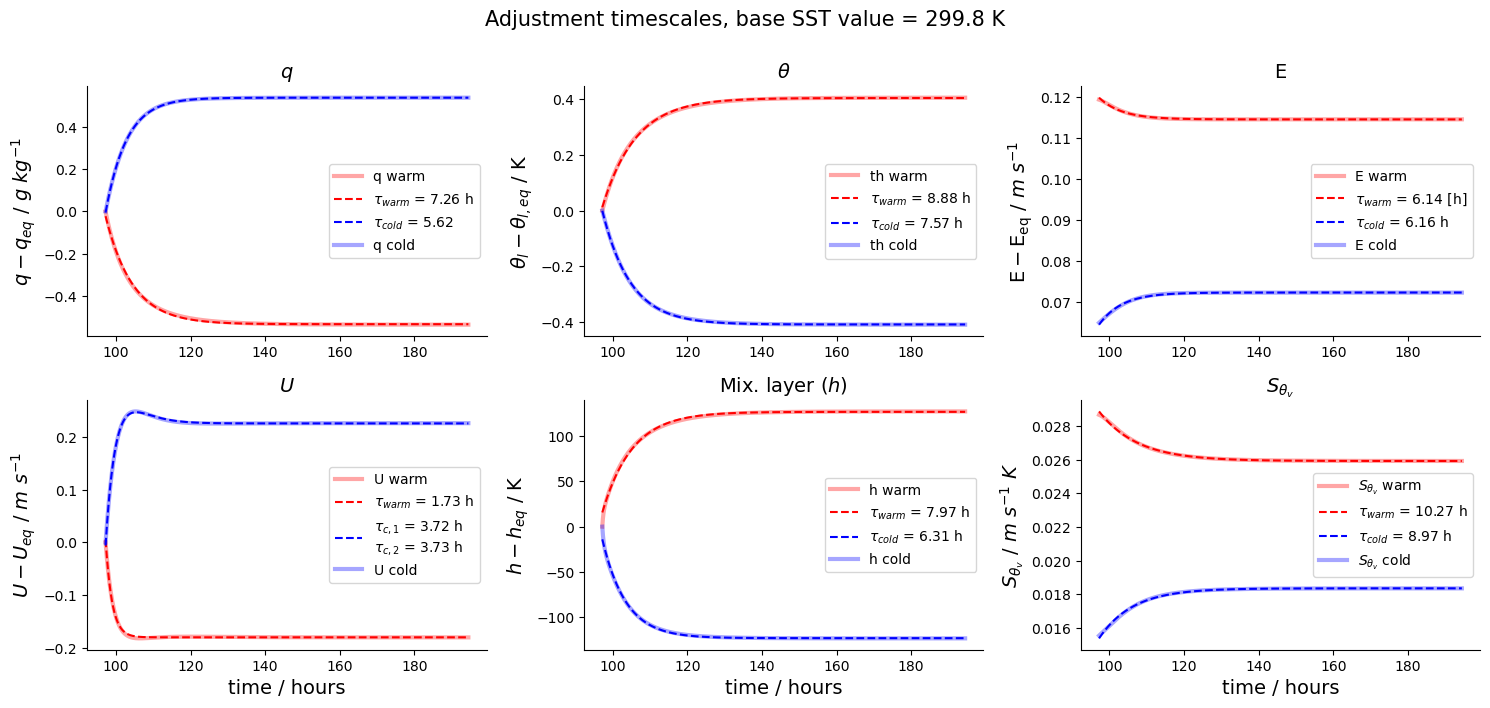

In [51]:
from scipy.optimize import curve_fit

def increasing_exp(x, a, b, c):  # "warm"
    return a*(1-np.exp(b*(x-c))) #(a+b*np.exp(c*(x-d)))

def double_exp(x, a, b, c, d, f, g, h):  
    return a+b*np.exp(c*(x-d)) + f*np.exp(g*(x-h))

def increasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_double_exp(x, a, b, c, d, f, g):  
    return a*(1-np.exp(b*(x-c))) + d*np.exp(f*(x-g))

def decreasing_exp(x, a, b, c):  # "cold"
    return a*np.exp(b*(x-c))



fig, ax = plt.subplots(2,3, figsize=(15, 7))
fig.suptitle(f"Adjustment timescales, base SST value = {SST_0} K", fontsize=15, y=1.005)

##################  moisture  ##################
var = 'q' 
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

x, y = time_warm, var_values_warm
y = y - y[0] #np.min(y)
y = y*1e3
initial_guess = [y[-1], -1/10, 100]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
tau_q_warm = np.abs(1/b)
ax[0,0].plot(x, y, 'r', label=f'{var} warm', alpha=0.35, linewidth=3)
ax[0,0].plot(x, increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} h')


x, y = time_cold, var_values_cold
y = y - y[0] #np.min(y)
y = y*1e3

initial_guess = [y[-1], -1/20, 100]

# Fit the data to the exponential model
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2]
tau_q_cold = np.abs(1/b)
ax[0,0].plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ = '+f"{np.abs(1/b):.2f}") #label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
ax[0,0].plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)

ax[0,0].set_title(r'$q$', fontsize=14)
# ax[0,0].set_xlabel("time / hours", fontsize=14)
ax[0,0].set_ylabel(r"$q - q_{eq}$ / $g~kg^{-1}$", fontsize=14)



###################   theta   ####################

var = 'th'
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

x, y = time_warm, var_values_warm
y = y - y[0]  #np.min(y)
initial_guess = [y[-1], -1/20, 100]
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])
a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
tau_th_warm = np.abs(1/b)
ax[0,1].plot(x, y, 'r', label=f'{var} warm', alpha=0.35, linewidth=3)
ax[0,1].plot(x, increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} h')


x, y = time_cold, var_values_cold
y = y - y[0]  #np.min(y)

initial_guess = [y[-1], -1/20, x[0]]
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2] #, fit_params[3]
tau_th_cold = np.abs(1/b)
ax[0,1].plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ ='+f' {np.abs(round(1/b,2))} h')
ax[0,1].plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)

ax[0,1].set_title(r'$\theta$', fontsize=14)
# ax[0,1].set_xlabel("time / hours", fontsize=14)
ax[0,1].set_ylabel(r"$\theta_l - \theta_{l, eq}$ / K", fontsize=14)




#####################  wind speed #####################
var = 'U' 
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)
x, y = time_warm, var_values_warm
y = y - y[0] #np.min(y)
initial_guess = [y[-1], -1/20, 100]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess) 

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
tau_U_warm = np.abs(1/b)
ax[1,0].plot(x, y, 'r', label=f'{var} warm', alpha=0.35, linewidth=3)
ax[1,0].plot(x,increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} h')


x, y = time_cold, var_values_cold
y = y - y[0] #np.min(y)

initial_guess = [y[-1], -y[-1], -1/5, x[0], (np.max(y)-y[-1]), -1/50, x[10]]  #[y[-1], -1/2, 100, np.max(y)-y[-1], -1/15, 110]
fit_params_cold, params_covar_cold = curve_fit(double_exp, x, y, p0=initial_guess, method="trf", maxfev=6000)
a, b, c, d, f, g, h = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2], fit_params_cold[3], fit_params_cold[4], fit_params_cold[5], fit_params_cold[6]
a, b, c, d, f, g, h = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2], fit_params_cold[3], fit_params_cold[4], fit_params_cold[5], fit_params_cold[6]
tau_U_cold = np.abs(1/c)
ax[1,0].plot(x, double_exp(x, a, b, c, d, f, g, h), '--b', label=r'$\tau_{c, 1}$ ='+f' {np.abs(round(1/c,2))} h \n'+ r'$\tau_{c, 2}$ ='+f' {np.abs(round(1/g,2))} h')

ax[1,0].plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)

ax[1,0].set_title(r'$U$', fontsize=14)
ax[1,0].set_xlabel("time / hours", fontsize=14)
ax[1,0].set_ylabel(r"$U - U_{eq}$ / $m~s^{-1}$", fontsize=14)


##################  MABL h  ###################

var = 'h'
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

x, y = time_warm, var_values_warm
y = y - y[0]  #np.min(y)
initial_guess = [y[-1], -1/20, x[0]]
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])

a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
tau_h_warm = np.abs(1/b)
ax[1,1].plot(x, y, 'r', label=f'{var} warm', alpha=0.35, linewidth=3)
ax[1,1].plot(x, increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} h')

x, y = time_cold, var_values_cold
y = y - y[0]  #np.min(y)
initial_guess = [y[-1], -1/20, x[0]]
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2] #, fit_params[3]
tau_h_cold = np.abs(1/b)
ax[1,1].plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ ='+f' {np.abs(round(1/b,2))} h')
ax[1,1].plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)


ax[1,1].set_title(r'Mix. layer ($h$)', fontsize=14)
ax[1,1].set_xlabel("time / hours", fontsize=14)
ax[1,1].set_ylabel(r"$h - h_{eq}$ / K", fontsize=14)





#################  Entrainment  #################
var = 'E'
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

x, y = time_warm, var_values_warm
y_fit = y - y[0] #np.min(y)
initial_guess = [y[-1], -1/10, x[0]]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y_fit, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])
a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
tauE_warm = np.abs(1/b)
ax[0,2].plot(x, y, 'r', label=f'{var} warm', alpha=0.35, linewidth=3)
ax[0,2].plot(x, y[0]+increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} [h]')


x, y = time_cold, var_values_cold
y = y #- y[0] #np.min(y)
initial_guess = [y[-1], -1/20, x[0]]

# Fit the data to the exponential model
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2]
tauE_cold = np.abs(1/b)
ax[0,2].plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ = '+f"{np.abs(1/b):.2f} h") #label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
ax[0,2].plot(x, y, 'b', label=f'{var} cold', alpha=0.35, linewidth=3)



ax[0,2].set_title(r'E', fontsize=14)
# ax[0,2].set_xlabel("time / hours", fontsize=14)
ax[0,2].set_ylabel(r"$\rm E - E_{eq}$ / $m~s^{-1}$", fontsize=14)




################## surface thv flux  ################
var = 'thv_flux_s'
time_warm, time_cold, var_values_warm, var_values_cold = set_variables_for_fit(var)

x, y = time_warm, var_values_warm
y_fit = y - y[0] #np.min(y)
initial_guess = [y[-1], -1/10, x[0]]

# Fit the data to the exponential model
fit_params_warm, params_covar_warm = curve_fit(increasing_exp, x, y_fit, p0=initial_guess)  # bounds=([0, 0, 0, -50], [100, 1000, 10,0])
a, b, c = fit_params_warm[0], fit_params_warm[1], fit_params_warm[2] #, fit_params[3]
tau_thvF_warm = np.abs(1/b)
ax[1,2].plot(x, y, 'r', label=r'$S_{\theta_v}$ warm', alpha=0.35, linewidth=3)
ax[1,2].plot(x, y[0]+increasing_exp(x, a, b, c), '--r', label=r'$\tau_{warm}$ ='+f' {np.abs(round(1/b,2))} h')


x, y = time_cold, var_values_cold
y = y #- y[0] #np.min(y)
initial_guess = [y[-1], -1/20, x[0]]

# Fit the data to the exponential model
fit_params_cold, params_covar_cold = curve_fit(increasing_exp, x, y, p0=initial_guess)
a, b, c = fit_params_cold[0], fit_params_cold[1], fit_params_cold[2]
tau_thvF_cold = np.abs(1/b)
ax[1,2].plot(x, increasing_exp(x, a, b, c), '--b', label=r'$\tau_{cold}$ = '+f"{np.abs(1/b):.2f} h") #label=r'$\tau_{c, growth}$ ='+f' {np.abs(round(1/c,2))} [h] \n'+ r'$\tau_{c, decay}$ ='+f' {np.abs(round(1/g,2))} [h]')
ax[1,2].plot(x, y, 'b', label=r'$S_{\theta_v}$ cold', alpha=0.35, linewidth=3)



ax[1,2].set_title(r'$S_{\theta_v}$', fontsize=14)
ax[1,2].set_xlabel("time / hours", fontsize=14)
ax[1,2].set_ylabel(r"$S_{\theta_v}$ / $m~s^{-1}~K$", fontsize=14)


### cosmetics
for x in ax.flatten():
    x.legend()
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)


plt.tight_layout()

# plt.savefig("/work/mh1498/m301248/TCO_data/QJRMS_0316/timescales_SST299.pdf")


In [51]:
ref_wind_speed_warm/3.6

np.float64(8.903834755451783)

In [48]:
import pandas as pd
from IPython.display import display, HTML

ref_wind_speed_cold = np.sqrt(U_cold[-1]**2 + V_cold[-1]**2) *3.6 #  km/h
ref_wind_speed_warm = np.sqrt(U_warm[-1]**2 + V_warm[-1]**2) *3.6 #  km/h
#ref_wind_speed      = np.sqrt(U_eq[-1]**2 + V_eq[-1]**2) *3.6 #  km/h 


data = [
    ["q",               np.round(tau_q_cold, 2),      np.round(tau_q_cold*ref_wind_speed_cold, 2)  ,    np.round(tau_q_warm, 2),  np.round(tau_q_warm*ref_wind_speed_warm, 2) ],
    [r"\theta",         np.round(tau_th_cold, 2),     np.round(tau_th_cold*ref_wind_speed_cold, 2)  ,   np.round(tau_th_warm, 2),  np.round(tau_th_warm*ref_wind_speed_warm, 2) ],
    [r"U",              np.round(tau_U_cold, 2),      np.round(tau_U_cold*ref_wind_speed_cold, 2) ,    np.round(tau_U_warm, 2),  np.round(tau_U_warm*ref_wind_speed_warm, 2) ],
    ["MABL h",          np.round(tau_h_cold, 2),      np.round(tau_h_cold*ref_wind_speed_cold, 2) ,    np.round(tau_h_warm, 2),  np.round(tau_h_warm*ref_wind_speed_warm, 2) ],
    ["E",               np.round(tauE_cold, 2),       np.round(tauE_cold*ref_wind_speed_cold, 2) ,     np.round(tauE_warm, 2),  np.round(tauE_warm*ref_wind_speed_warm, 2) ],
    [r"$S_{\theta_v}$", np.round(tau_thvF_cold,2),    np.round(tau_thvF_cold*ref_wind_speed_cold, 2),  np.round(tau_thvF_warm, 2), np.round(tau_thvF_warm*ref_wind_speed_warm, 2)]

    #[r"$S_{\theta_v}$", tau_thvF_cold,   tau_thvF_cold*ref_wind_speed_cold  , tau_thvF_warm,  tau_thvF_warm*ref_wind_speed_warm ],
]

# Create DataFrame
df = pd.DataFrame(data, columns=["Quantity", r"$\tau$ cold / h", "scale cold / km", r"$\tau$ warm / h",  "scale warm / km"])

display(HTML(df.to_html(index=False, table_id="summary-table")))

print(df.to_latex(
    index=False,          # drop row indices
    columns=["Quantity", r"$\tau$ cold / h", "scale cold / km", r"$\tau$ warm / h",  "scale warm / km"],   # select specific columns
    float_format="%.2f",  # format floats
    caption=f"Time and length scales for base SST={SST_0}",   # add caption
    label="tab:timescales_SST300",  # \label for \ref
    position="h",         # [h] placement specifier
    column_format="ccccc",  # manual column alignment (l, c, r)
    escape=True,          # escape special LaTeX characters
    bold_rows=False,
))

Quantity,$\tau$ cold / h,scale cold / km,$\tau$ warm / h,scale warm / km
q,5.62,171.85,7.26,232.61
\theta,7.57,231.55,8.88,284.70
U,3.72,113.64,1.73,55.60
MABL h,6.31,192.95,7.97,255.60
E,6.16,188.29,6.14,196.67
$S_{\theta_v}$,8.97,274.27,10.27,329.11


\begin{table}[h]
\caption{Time and length scales for base SST=299.8}
\label{tab:timescales_SST300}
\begin{tabular}{ccccc}
\toprule
Quantity & \$\textbackslash tau\$ cold / h & scale cold / km & \$\textbackslash tau\$ warm / h & scale warm / km \\
\midrule
q & 5.62 & 171.85 & 7.26 & 232.61 \\
\textbackslash theta & 7.57 & 231.55 & 8.88 & 284.70 \\
U & 3.72 & 113.64 & 1.73 & 55.60 \\
MABL h & 6.31 & 192.95 & 7.97 & 255.60 \\
E & 6.16 & 188.29 & 6.14 & 196.67 \\
\$S\_\{\textbackslash theta\_v\}\$ & 8.97 & 274.27 & 10.27 & 329.11 \\
\bottomrule
\end{tabular}
\end{table}



## Fig. 4: open data for SST equilibrium sensitivities

In [3]:
import pickle
path = '/path/to/bulk_equilibrium_sensitivities.pickle'
with open(path, 'rb') as handle:
    collect_eq = pickle.load(handle)

SST_forced = collect_eq['SST values']
collect_eq.pop('SST values')


label_fracUstar = collect_eq['frac_Ustar']
collect_eq.pop('frac_Ustar')

# remove intermediate case q_free = 7.0 g/kg
collect_eq.pop('7.0')

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/bulk_equilibrium_sensitivities.pickle'

## draw Fig. 4

/venus/tesi_ale/img_bulk/SST_sens_qfree_final.pdf


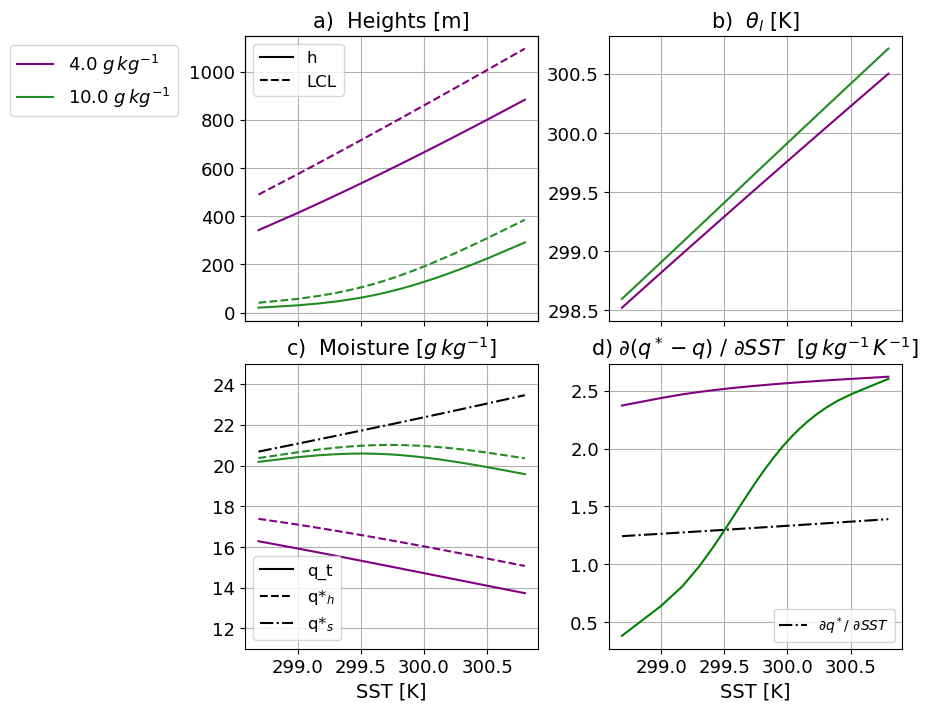

In [47]:
# sys.path.append('/home/alessandro/thesis_material/EURECA_scripts/ABL_BULK/')
# import neggers_stevens
import matplotlib.lines as mlines
#################################################################################################

colors = ['purple', 'forestgreen']
legend_entries = [ str(float(x)) for x in collect_eq.keys()]

fig, ax = plt.subplots(2,2,figsize=(9,7),sharex=True,constrained_layout=True)

#########  h and LCL  ###########
solid_line = mlines.Line2D([], [], color='k', label='h', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label='LCL', linestyle='--')
ax[0,0].set_title('a)  Heights [m]', fontsize=15)
ax[0,0].grid()

for i, moist in enumerate(collect_eq.keys()):
    ax[0,0].plot(SST_forced, collect_eq[moist]['h_eq'], '-', color=colors[i], label=legend_entries[i]+r' $g\,kg^{-1}$')
    ax[0,0].plot(SST_forced, collect_eq[moist]['LCL_eq'], '--', color=colors[i])

ax[0,0].legend(fontsize=13, bbox_to_anchor=(-0.2, 1))
finto = ax[0,0].twinx()
finto.tick_params(axis='y', which='both', left=False, right=False, labelright=False)
finto.legend(handles=[solid_line, dashed_line], loc='upper left', fontsize=12)




#######  temperature  ########
ax[0,1].set_title(r'b)  $\theta_l$ [K]', fontsize=15)
ax[0,1].grid()

for i, moist in enumerate(collect_eq.keys()):
    ax[0,1].plot(SST_forced, collect_eq[moist]['th_eq'],  '-', color=colors[i],)

    
#########  moisture  ##########
solid_line = mlines.Line2D([], [], color='k', label='q_t', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label='q*$_h$', linestyle='--')

q_star = ax[1,0].plot(SST_forced, neggers_stevens.qsea(SST_forced-273.15,1000), '-.k', label='q*$_s$')

for i, moist in enumerate(collect_eq.keys()):
    ax[1,0].plot(SST_forced, collect_eq[moist]['q_eq'] * 1e3, '-', color=colors[i])
    ax[1,0].plot(SST_forced, collect_eq[moist]['qsat_eq'] * 1e3, '--', color=colors[i])

# ax[0,2].legend(fontsize=14)
ax[1,0].legend(handles=[solid_line, dashed_line, q_star[0]], loc='lower left',  fontsize=12)
ax[1,0].set_title(r'c)  Moisture [$g\,kg^{-1}$]', fontsize=15)
ax[1,0].grid()
ax[1,0].set_ylim(11,25)
    
    

##########  alpha_LHF ############
q_star = neggers_stevens.qsea(SST_forced-273.15,1000)
q_4 = np.array(collect_eq['4.0']['q_eq'])*1e3
q_10 = np.array(collect_eq['10.0']['q_eq'])*1e3

dq4_dSST  = mpcalc.first_derivative(q_4, x=SST_forced )
dq10_dSST = mpcalc.first_derivative(q_10, x=SST_forced )
dqstar_dSST = mpcalc.first_derivative(q_star, x=SST_forced )

# solid_line_hf = mlines.Line2D([], [], color='k', label='LHF', linestyle='-')
# dashed_line_hf = mlines.Line2D([], [], color='k', label='LHF CC', linestyle='--')


ax[1,1].plot(SST_forced, dqstar_dSST - dq4_dSST, color='purple')
ax[1,1].plot(SST_forced, dqstar_dSST - dq10_dSST, color='green')
ax[1,-1].plot(SST_forced, dqstar_dSST , label=r'$\partial q^* /~ \partial SST$ ', color='k', linestyle='-.')

# ax[1,1].legend(handles=[solid_line_hf, dashed_line_hf], loc='upper left', fontsize=12)
ax[1,1].legend()
ax[1,1].set_title(r'd) $\partial (q^* - q) ~/~ \partial SST$  [$g\,kg^{-1}\,K^{-1}$] ', fontsize=15)
ax[1,1].grid()
ax[1,1].set_ylabel('')
ax[1,1].tick_params(axis='y', labelsize=14)


###########################################à

for i in range(2):
    ax[1,i].set_xlabel('SST [K]', fontsize=14)

for axs_row in ax:
    for axs in axs_row:
        axs.tick_params(axis='both', which='major', labelsize=13) 



#### fig 4 reviewed

In [ ]:
path = 'SST_percentiles_forced.npy'
with open(path, 'rb') as handle:
    SST_forced = np.load(handle)

print("SST percentiles from the WRF simulation:")
SST_forced

SST percentiles from the WRF simulation:


array([298.69082642, 298.99957275, 299.17059326, 299.30218506,
       299.41305542, 299.50689697, 299.59078979, 299.66952515,
       299.74584961, 299.81939697, 299.88983154, 299.95932007,
       300.0274353 , 300.09402466, 300.16131592, 300.23284912,
       300.31008911, 300.39743042, 300.51516724, 300.79766846])

In [4]:
U_free = -9.4 # [m/s], free zonal wind (above the ABL).
V_free = -3.3 # [m/s], free meridional wind (above the ABL).

print(U_free)
print(V_free)

Omega = 2*np.pi/86400 # [rad/s] Earth rotation.
latitude0 = 10 # degree N
f = Omega * np.sin(latitude0*np.pi/180)

-9.4
-3.3


In [ ]:
#############################   CHOICE OF MODEL EQUATIONS  #################################
equations_model = bulk_model_code.neggers_et_al_2006_stevens_et_al_2002_fracUstar


#######################  set parameters and initial conditions from here on  #####################
frac_Ustar = 0.9

# Initial conditions: y0 = [h(0),q(0),th(0),U(0),V(0)]
cpd  = 1004.67                  # J/K/kg, dry air specific heat at constant pressure
Rd = 287.1                      # J/K/kg, dry air gas constant

####  set initial conditions - from WRF simulation ####
 
# Input parameters
D_0 = -4.6e-7                                   # [1/s], large scale divergence
ps_0 = 1013                                     # [hPa], surface pressure
ref_p = 1000                                    # reference pressure for the potential temperature
th_free_0 = 305.16                              # [K], free tropospheric liquid virtual potential temperature


## set integration times
max_t = 7e5
dt_max = 60
time = [0, max_t]

In [6]:
results_collector = {}

In [7]:
q_free_vals = [4e-3, 12e-3]         # 4.0e-3, 10.0e-3          # [kg/kg] free tropospheric total mixing ratio
frac_Ustar = 0.9

for q_free in q_free_vals:
    h, q, th, U, V = np.zeros_like(SST_forced), np.zeros_like(SST_forced), np.zeros_like(SST_forced), np.zeros_like(SST_forced), np.zeros_like(SST_forced)
    diagnostics = {}

    for jj, SST in enumerate(SST_forced):
        print(f"Running bulk model for SST = {SST} K")

        th_s = SST*(ref_p/ps_0)**(Rd/cpd) # surface liquid water potential temperature, assuming no liquid water at the surface
        q_s = bulk_model_code.qsea(SST-273.15,ps_0)*1e-3

        # adjust initial conditions (boundary layer humidity) depending on SST value!
        y0 = [500, q_s - 5e-3, th_s-3, U_free, V_free]  

        args = (SST, D_0, q_free, th_free_0, ps_0, f, U_free, V_free, frac_Ustar)


        ###  INTEGRATE THE EQUATIONS TO REACH THE INITIAL EQUILIBRIUM
        sol_NS = solve_ivp(equations_model, [0,t_split], y0, t_eval = t_eval_eq,\
                            dense_output=True, max_step=dt_max, args=args)
        
        h[jj], q[jj], th[jj], U[jj], V[jj] = sol_NS.y[:,-1]

        diagnostics[str(SST)] = bulk_model_code.compute_diagnostics(sol_NS.y[:,-1], SST, ps_0, q_free, th_free_0, frac_Ustar)

    results_collector[str(q_free)] = {"sst_values": SST_forced, "h": h, "q": q, "th": th, "U": U, "V": V, "diagnostics": diagnostics}
    print(f"Finished bulk model for q_free = {q_free} kg/kg")


Running bulk model for SST = 298.6908264160156 K
Running bulk model for SST = 298.99957275390625 K
Running bulk model for SST = 299.17059326171875 K
Running bulk model for SST = 299.30218505859375 K
Running bulk model for SST = 299.4130554199219 K
Running bulk model for SST = 299.50689697265625 K
Running bulk model for SST = 299.5907897949219 K
Running bulk model for SST = 299.6695251464844 K
Running bulk model for SST = 299.745849609375 K
Running bulk model for SST = 299.81939697265625 K
Running bulk model for SST = 299.88983154296875 K
Running bulk model for SST = 299.9593200683594 K
Running bulk model for SST = 300.0274353027344 K
Running bulk model for SST = 300.0940246582031 K
Running bulk model for SST = 300.16131591796875 K
Running bulk model for SST = 300.23284912109375 K
Running bulk model for SST = 300.3100891113281 K
Running bulk model for SST = 300.3974304199219 K
Running bulk model for SST = 300.5151672363281 K
Running bulk model for SST = 300.79766845703125 K
Finished bul

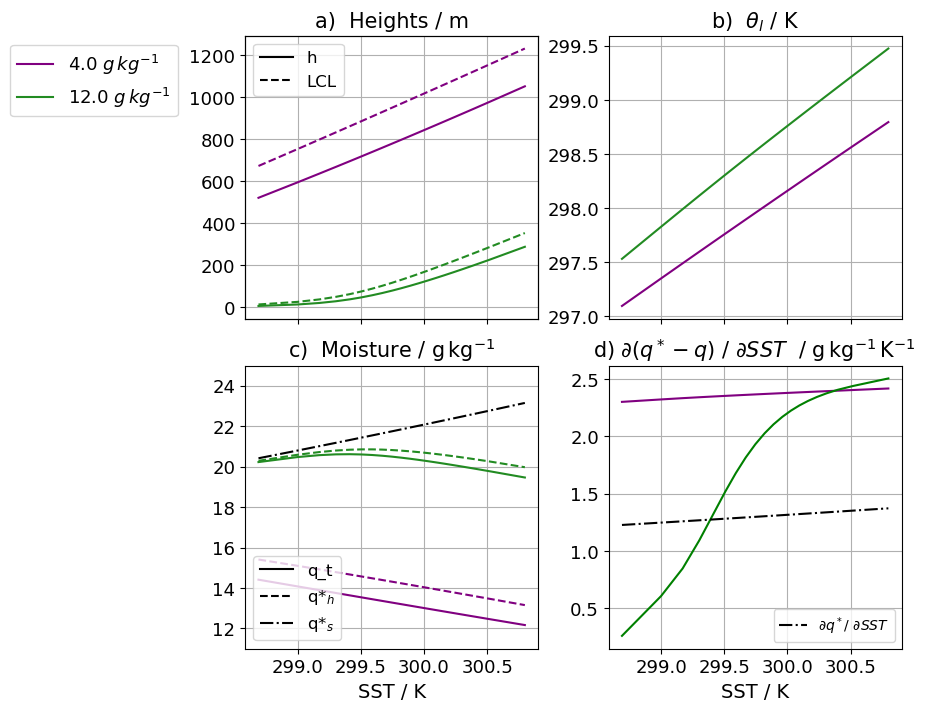

In [11]:
# sys.path.append('/home/alessandro/thesis_material/EURECA_scripts/ABL_BULK/')
# import neggers_stevens
import matplotlib.lines as mlines
import metpy.calc as mpcalc
#################################################################################################

colors = ['purple', 'forestgreen']
legend_entries = [ str(float(x)*1e3) for x in results_collector.keys()]

fig, ax = plt.subplots(2,2,figsize=(9,7),sharex=True,constrained_layout=True)

#########  h and LCL  ###########
solid_line = mlines.Line2D([], [], color='k', label='h', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label='LCL', linestyle='--')
ax[0,0].set_title('a)  Heights / m', fontsize=15)
ax[0,0].grid()

for i, moist in enumerate(results_collector.keys()):
    ax[0,0].plot(SST_forced, results_collector[moist]['h'], '-', color=colors[i], label=legend_entries[i]+r' $g\,kg^{-1}$')
    LCL_values = [results_collector[moist]['diagnostics'][str(sst)]['LCL'] for sst in SST_forced]
    ax[0,0].plot(SST_forced, LCL_values, '--', color=colors[i])

ax[0,0].legend(fontsize=13, bbox_to_anchor=(-0.2, 1))
finto = ax[0,0].twinx()
finto.tick_params(axis='y', which='both', left=False, right=False, labelright=False)
finto.legend(handles=[solid_line, dashed_line], loc='upper left', fontsize=12)




#######  temperature  ########
ax[0,1].set_title(r'b)  $\theta_l$ / K', fontsize=15)
ax[0,1].grid()

for i, moist in enumerate(results_collector.keys()):
    ax[0,1].plot(SST_forced, results_collector[moist]['th'],  '-', color=colors[i],)

    
#########  moisture  ##########
solid_line = mlines.Line2D([], [], color='k', label='q_t', linestyle='-')
dashed_line = mlines.Line2D([], [], color='k', label='q*$_h$', linestyle='--')

q_star = ax[1,0].plot(SST_forced, bulk_model_code.qsea(SST_forced-273.15,ps_0), '-.k', label='q*$_s$')

for i, moist in enumerate(results_collector.keys()):
    ax[1,0].plot(SST_forced, results_collector[moist]['q'] * 1e3, '-', color=colors[i])
    qSat_values = [results_collector[moist]['diagnostics'][str(sst)]['qsat'] * 1e3 for sst in SST_forced]
    ax[1,0].plot(SST_forced, qSat_values , '--', color=colors[i])

# ax[0,2].legend(fontsize=14)
ax[1,0].legend(handles=[solid_line, dashed_line, q_star[0]], loc='lower left',  fontsize=12)
ax[1,0].set_title(r'c)  Moisture / $\rm g\,kg^{-1}$', fontsize=15)
ax[1,0].grid()
ax[1,0].set_ylim(11,25)
    
    

##########  alpha_LHF ############
q_star = bulk_model_code.qsea(SST_forced-273.15,ps_0)
q_4 = np.array(results_collector['0.004']['q'])*1e3
q_10 = np.array(results_collector['0.012']['q'])*1e3

dq4_dSST  = mpcalc.first_derivative(q_4, x=SST_forced )
dq10_dSST = mpcalc.first_derivative(q_10, x=SST_forced )
dqstar_dSST = mpcalc.first_derivative(q_star, x=SST_forced )

# solid_line_hf = mlines.Line2D([], [], color='k', label='LHF', linestyle='-')
# dashed_line_hf = mlines.Line2D([], [], color='k', label='LHF CC', linestyle='--')


ax[1,1].plot(SST_forced, dqstar_dSST - dq4_dSST, color='purple')
ax[1,1].plot(SST_forced, dqstar_dSST - dq10_dSST, color='green')
ax[1,-1].plot(SST_forced, dqstar_dSST , label=r'$\partial q^* /~ \partial SST$ ', color='k', linestyle='-.')

# ax[1,1].legend(handles=[solid_line_hf, dashed_line_hf], loc='upper left', fontsize=12)
ax[1,1].legend()
ax[1,1].set_title(r'd) $\partial (q^* - q) ~/~ \partial SST$  / $\rm g\,kg^{-1}\,K^{-1}$ ', fontsize=15)
ax[1,1].grid()
ax[1,1].set_ylabel('')
ax[1,1].tick_params(axis='y', labelsize=14)


###########################################à

for i in range(2):
    ax[1,i].set_xlabel('SST / K', fontsize=14)

for axs_row in ax:
    for axs in axs_row:
        axs.tick_params(axis='both', which='major', labelsize=13) 


# plt.savefig("/work/mh1498/m301248/TCO_data/QJRMS_0316/fig04_rev.pdf", dpi=300)

In [10]:
results_collector

{'0.004': {'sst_values': array([298.69082642, 298.99957275, 299.17059326, 299.30218506,
         299.41305542, 299.50689697, 299.59078979, 299.66952515,
         299.74584961, 299.81939697, 299.88983154, 299.95932007,
         300.0274353 , 300.09402466, 300.16131592, 300.23284912,
         300.31008911, 300.39743042, 300.51516724, 300.79766846]),
  'h': array([ 520.26493069,  593.66649262,  635.05224511,  667.22776034,
          694.55238369,  717.83038552,  738.75484041,  758.48951112,
          777.70795435,  796.30814661,  814.19485454,  831.91134118,
          849.34462051,  866.45091208,  883.80088193,  902.31394917,
          922.3837242 ,  945.17734426,  976.06876188, 1050.95768854]),
  'q': array([0.01441337, 0.01408187, 0.01389816, 0.01375689, 0.01363797,
         0.01353742, 0.01344762, 0.01336343, 0.0132819 , 0.01320343,
         0.01312837, 0.01305441, 0.01298199, 0.01291129, 0.01283993,
         0.01276417, 0.0126825 , 0.01259031, 0.01246631, 0.01217014]),
  'th': array([

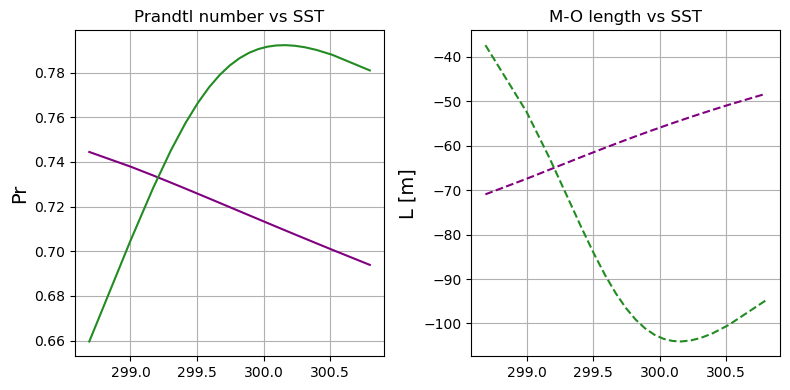

In [23]:
## plotting evolution of Pr and L
z = 10

fig, ax = plt.subplots(1,2,figsize=(8,4))

for i, moist in enumerate(collect_eq.keys()):
    pr = collect_eq[moist]['we_dyn_eq'] / collect_eq[moist]['E_eq']
    L = 16*z/(1-pr**(-4))
    
    ax[0].plot(SST_forced, pr,  '-', color=colors[i])
    ax[1].plot(SST_forced, L,  '--', color=colors[i])

ax[0].set_title('Prandtl number vs SST')
ax[0].set_ylabel('Pr',fontsize=14)
ax[0].grid('dashed')


ax[1].set_title('M-O length vs SST')
ax[1].grid('dashed')
ax[1].set_ylabel('L [m]',fontsize=14)

plt.tight_layout()


## Fig. 3: sensitivity of forcing terms in bulk equations

In [7]:
magnitude = 8.75 # [m/s]
angle = 67.5 # [°] clockwise from north
windu = magnitude*np.sin(angle*np.pi/180)
windv = magnitude*np.cos(angle*np.pi/180)

Omega = 2*np.pi/86400 # [rad/s] Earth rotation.
latitude0 = 10 # degree N
f = Omega * np.sin(latitude0*np.pi/180)

CD = 1/900.                            # drag coefficient.

U_free, V_free = -windu, -windv

In [4]:
path = '/path/to/bulk_equilibrium_sensitivities.pickle'
import pickle

with open(path, 'rb') as handle:
    collect_eq = pickle.load(handle)
    
SST_values = collect_eq['SST values']
collect_eq.pop('SST values')

frac_Ustar = collect_eq['frac_Ustar']
collect_eq.pop('frac_Ustar')

## I only want data from q_free = 4.0 g/kg
## i.e. the realistic scenario
q_free ='4.0'

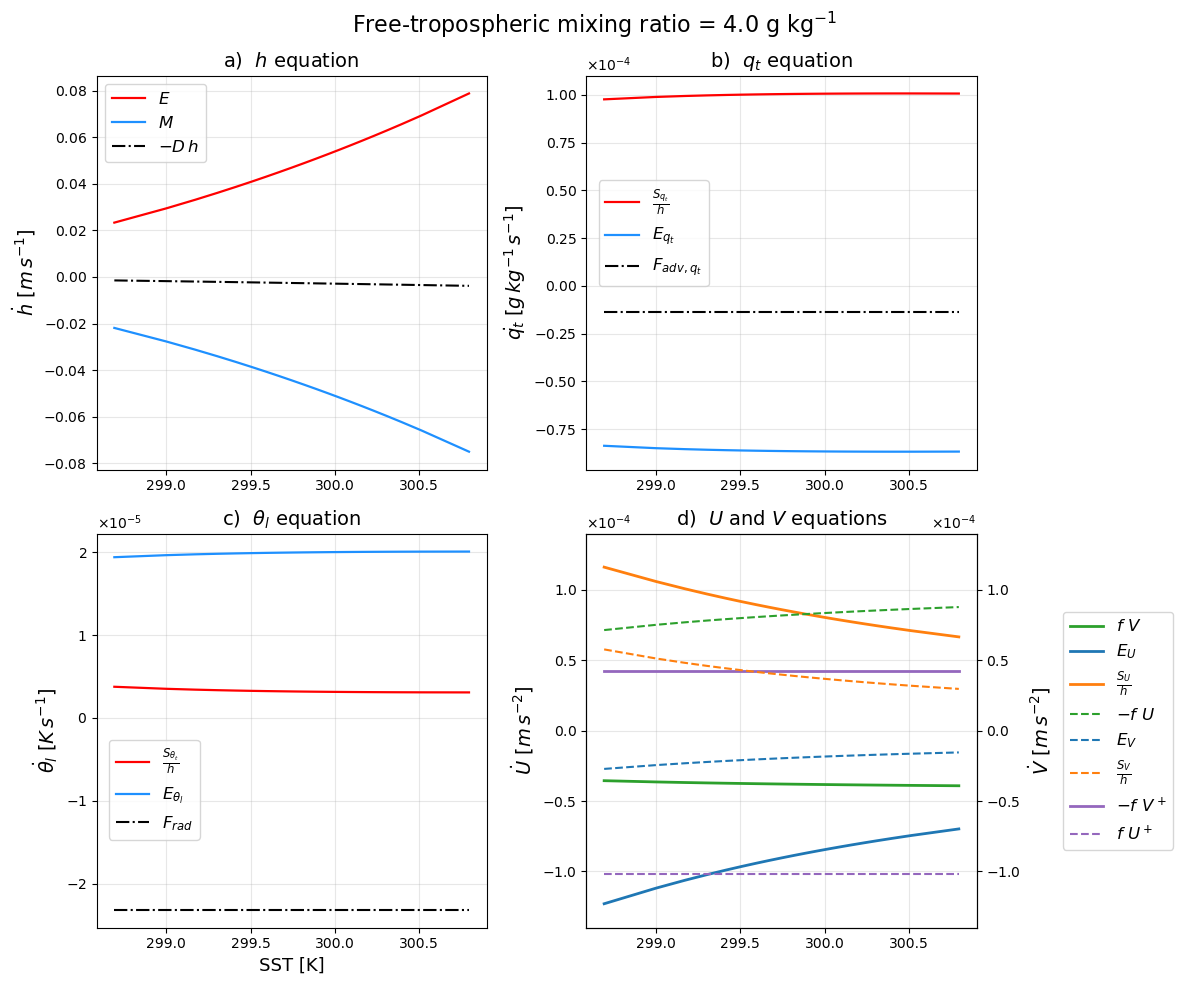

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"Free-tropospheric mixing ratio = {q_free} " + r"$\rm g~kg^{-1}$", fontsize=16)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

### --- Top Left: h Equation --- ###
div = 4.3e-6
M = collect_eq[q_free]['M_eq']
E = collect_eq[q_free]['E_eq']
subsidence = div * collect_eq[q_free]['h_eq']

ax[0, 0].plot(SST_values, E, '-r', label=r"$E$", linewidth=1.6)
ax[0, 0].plot(SST_values, -M, color='dodgerblue', label=r"$M$", linewidth=1.6)
ax[0, 0].plot(SST_values, -subsidence, '-.', color='k', label=r"$-D\,h$")
ax[0, 0].set_title(r"a)  $h$ equation", fontsize=14)
# ax[0, 0].set_xlabel('SST [K]', fontsize=13)
ax[0, 0].set_ylabel(r"$\dot{h}$ [$m\,s^{-1}$]", fontsize=14)
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(loc='upper left', fontsize=12)
ax[0, 0].yaxis.set_major_formatter(formatter)

### --- Top Right: Moisture Equation --- ###
q_flux_s = collect_eq[q_free]['q_flux_s_eq']
delta_q  = collect_eq[q_free]['C_delta_q_eq']
h        = collect_eq[q_free]['h_eq']
F_advq   = -1.2e-3 / 86400 * np.ones_like(SST_values)

ax[0, 1].plot(SST_values, q_flux_s * 1e3 / h, '-r', label=r"$\frac{S_{q_t}}{h}$", linewidth=1.6)
ax[0, 1].plot(SST_values, E * delta_q * 1e3 / h, color='dodgerblue', label=r"$E_{q_t}$", linewidth=1.6)
ax[0, 1].plot(SST_values, F_advq * 1e3, '-.', color='k', label=r"$F_{adv, q_t}$")
ax[0, 1].set_title(r"b)  $q_t$ equation", fontsize=14)
# ax[0, 1].set_xlabel('SST [K]', fontsize=13)
ax[0, 1].set_ylabel(r"$\dot{q_t}$ [$g\,kg^{-1}\,s^{-1}$]", fontsize=14)
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(loc='center left', fontsize=12, bbox_to_anchor=(0.01, 0.6))
ax[0, 1].yaxis.set_major_formatter(formatter)

### --- Bottom Left: Theta Equation --- ###
th_flux_s = collect_eq[q_free]['th_flux_s_eq']
delta_th  = collect_eq[q_free]['C_delta_th_eq']
F_rad     = -2.0 / 86400 * np.ones_like(SST_values)

ax[1, 0].plot(SST_values, th_flux_s / h, '-r', label=r"$\frac{S_{\theta_t}}{h}$", linewidth=1.6)
ax[1, 0].plot(SST_values, E * delta_th / h,  color='dodgerblue', label=r"$E_{\theta_l}$", linewidth=1.6)
ax[1, 0].plot(SST_values, F_rad, '-.', color='k', label=r"$F_{rad}$")
ax[1, 0].set_title(r"c)  $\theta_l$ equation", fontsize=14)
ax[1, 0].set_xlabel('SST [K]', fontsize=13)
ax[1, 0].set_ylabel(r"$\dot{\theta_l}$ [$K\,s^{-1}$]", fontsize=14)
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(loc='center left', fontsize=12, bbox_to_anchor=(0.01, 0.35))
ax[1, 0].yaxis.set_major_formatter(formatter)

### --- Bottom Right: U and V Equation --- ###
U, V = collect_eq[q_free]['U_eq'], collect_eq[q_free]['V_eq']
we_dyn = collect_eq[q_free]['we_dyn_eq']

lns1 = ax[1, 1].plot(SST_values, f * V,  label=r"$f~V$", color='tab:green', linewidth=2)
lns7 = ax[1, 1].plot(SST_values, -np.ones_like(SST_values) * f * V_free,  label=r"$-f~V^+$", color='tab:purple', linewidth=2)
lns2 = ax[1, 1].plot(SST_values, we_dyn * (U_free - U) / h,  color='tab:blue', label=r"$E_U$", linewidth=2)
lns3 = ax[1, 1].plot(SST_values, -CD * U * np.sqrt(U**2 + V**2) / h,  label=r"$\frac{S_U}{h}$", color='tab:orange', linewidth=2)
ax[1, 1].set_ylabel(r'$\dot{U}$ [$m\,s^{-2}$]', fontsize=14)
ax[1, 1].set_ylim([-14e-5, 14e-5])
ax[1, 1].yaxis.set_major_formatter(formatter)
ax[1, 1].grid(alpha=0.3)
ax[1, 1].set_title(r"d)  $U$ and $V$ equations", fontsize=14)

ax2r = ax[1, 1].twinx()
lns4 = ax2r.plot(SST_values, -f * U , linestyle='--', label=r"$-f~U$", color='tab:green')
lns8 = ax2r.plot(SST_values, np.ones_like(SST_values) * f * U_free , linestyle='--', label=r"$f~U^+$", color='tab:purple')
lns5 = ax2r.plot(SST_values, we_dyn * (V_free - V) / h, linestyle='--', color='tab:blue', label=r"$E_V$")
lns6 = ax2r.plot(SST_values, -CD * V * np.sqrt(U**2 + V**2) / h,  linestyle='--', label=r"$\frac{S_V}{h}$", color='tab:orange')
ax2r.set_ylabel(r'$\dot{V}$ [$m\,s^{-2}$]', fontsize=14)
ax2r.set_ylim([-14e-5, 14e-5])
ax2r.yaxis.set_major_formatter(formatter)

lns = lns1 + lns2 + lns3 + lns4 + lns5 + lns6 + lns7 + lns8
labs = [l.get_label() for l in lns]
ax[1, 1].legend(lns, labs, loc='center left', bbox_to_anchor=(1.2, 0.5), fontsize=12)

# Layout fix
plt.tight_layout()
# plt.subplots_adjust(top=0.05, left=0.08, right=0.92)


## understanding whether dessication is more important than MABL growth

In [2]:
import metpy.calc as mpcalc

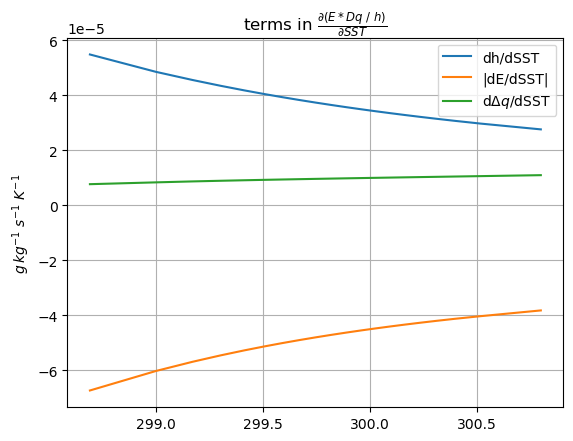

In [10]:
E = collect_eq[q_free]['E_eq']
delta_q  = collect_eq[q_free]['C_delta_q_eq']*1e3
h        = collect_eq[q_free]['h_eq']

h_growth = -E*delta_q*mpcalc.first_derivative(h, x=SST_values )/h**2
E_growth = (delta_q/h)*mpcalc.first_derivative(E, x=SST_values )
deltaQ_growth = (E/h)*mpcalc.first_derivative(delta_q, x=SST_values )


plt.plot(SST_values, h_growth, label='dh/dSST')
plt.plot(SST_values, E_growth, label='|dE/dSST|')
plt.plot(SST_values, deltaQ_growth, label=r'd$\Delta q$/dSST ')
plt.ylabel(r"$g\,kg^{-1}~s^{-1}~K^{-1}$")
plt.title(r"terms in $\frac{\partial(E*Dq~/~h) }{ \partial SST}$")

plt.legend()
plt.grid()

starting from the equilibrium condition for $q_t$
\begin{equation}
    C_q U (q^*-q_t) = -E*C_h*(q^+-q_t) - h*F_{adv,q}
\end{equation}
one may isolate $q_t$ to get

\begin{equation}
    q_t = C_q ~ \frac{U q^*}{C_h E + C_q U} + C_H q^+ \frac{E}{C_h E + C_q U} + F_a \frac{h}{C_h E + C_q U}
\end{equation}
by applying derivative to both sides, we obtain 
\begin{align}
    \textcolor{purple}{\frac{\partial q_t}{\partial SST}} = \frac{1}{(C_q U + C_H E)^2} * \\
    &\textcolor{red}{\frac{\partial U}{\partial SST}}   \left( C_q C_H E q^* - C_q C_H q^+ E - C_q F_a h \right) + \nonumber \\
    &\textcolor{green}{\frac{\partial E}{\partial SST}}    \left( -C_q C_H U q^* + C_q C_H U q^+ - C_H F_a h \right) + \nonumber \\
    &\textcolor{orange}{\frac{\partial q^*}{\partial SST}}  \left( C_q C_H E U + C_q^2 U^2 \right) + \nonumber \\
    &\textcolor{blue}{\frac{\partial h}{\partial SST}}    \left( C_H E F_a + C_q U F_a \right) \\
\end{align}


In [33]:
q_free = '4.0'

Cq = 0.0012 
CH = 0.1 
Fa = -1.2e-3/86400
q_plus = float(q_free)/1000

def qsat(t,p):
    """
    usage: es = qsat(t,p)
    Returns saturation vapor pressure es (mb) given t(C) and p(mb).
    After Buck, 1981: J.Appl.Meteor., 20, 1527-1532
    Returns ndarray float for any numeric object input.
    """
    from numpy import copy, asarray, exp

    t2 = copy(asarray(t, dtype=float))  # convert to ndarray float
    p2 = copy(asarray(p, dtype=float))
    es = 6.1121 * exp(17.502 * t2 / (240.97 + t2))
    es = es * (1.0007 + p2 * 3.46e-6)
    return es
    
def qsea(sst,p):
    """in 
    usage: qs = qsea(sst,p)
    Returns saturation specific humidity (g/kg) at sea surface
    given sst(C) and p(mb) input of any numeric type.
    Returns ndarray float for any numeric object input.
    """
    ex = qsat(sst,p) # returns ex as ndarray float
    es = ex#0.98 * ex # This is the correction for the effect of salinity, which we remove now
    qs = 622*es/(p-0.378*es) # saturation specific humidity
    return qs

q_star = qsea(SST_values-273.15,1015)/1000

U = np.sqrt( (collect_eq[q_free]['U_eq'])**2 + (collect_eq[q_free]['V_eq'])**2 )
E = collect_eq[q_free]['E_eq']
q = collect_eq[q_free]['q_eq']
h = collect_eq[q_free]['h_eq']

denominator = (Cq*U+CH*E)**2

dh_dsst_term         = (CH*Fa*E + Cq*U*Fa)*mpcalc.first_derivative(h, x=SST_values )
dqstar_dsst_term     = (Cq*CH*E*U + (Cq**2)*U**2)*mpcalc.first_derivative(q_star, x=SST_values )
dE_dsst_term         = (-Cq*CH*U*q_star + Cq*CH*U*q_plus - CH*h*Fa)*mpcalc.first_derivative(E, x=SST_values )
dU_dsst_term         = (Cq*CH*E*q_star - Cq*CH*q_plus*E - Cq*Fa*h)*mpcalc.first_derivative(U, x=SST_values )

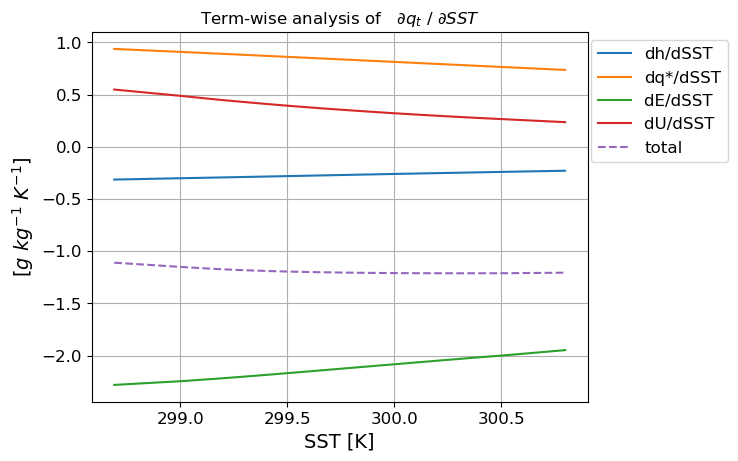

In [34]:
plt.plot(SST_values, 1e3*dh_dsst_term/denominator, label='dh/dSST')
plt.plot(SST_values, 1e3*dqstar_dsst_term/denominator, label='dq*/dSST')
plt.plot(SST_values, 1e3*dE_dsst_term/denominator, label=r'dE/dSST ')
plt.plot(SST_values, 1e3*dU_dsst_term/denominator, label=r'dU/dSST ')
plt.plot(SST_values, 1e3*(dh_dsst_term + dqstar_dsst_term+dE_dsst_term+dU_dsst_term)/denominator, label='total', linestyle='--')

# plt.plot(SST_values, mpcalc.first_derivative(q, x=SST_values ), label=r'dq/dSST ', linestyle='--')

plt.ylabel(r"[$g~kg^{-1}~K^{-1}$]", fontsize=14)
plt.xlabel("SST [K]", fontsize=14)
plt.title(r"Term-wise analysis of   $\partial q_t ~ / ~ \partial SST$")
plt.legend(bbox_to_anchor=(1.3, 1.), fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid()